# AuditorAgent Synthetic Training Dataset — Comprehensive Validation & Cleaning Pipeline

**Author:** Damika | **Date:** March 2026  
**Dataset:** 750 JSONL rows generated via Gemini for fine-tuning an architectural governance AuditorAgent  
**Purpose:** Research-grade data quality assessment, bias detection, cleaning, and before/after evaluation

---

## Table of Contents

| # | Section | Purpose |
|---|---------|---------|
| 0 | Setup & Configuration | Imports, constants, helper functions |
| 1 | Data Loading & JSONL Parsing | Robust line-by-line ingestion with error handling |
| 2 | Audit Chain Reconstruction | Group rows into multi-round project audit chains |
| 3 | Structural Schema Validation | Recursive nested key/type/presence checks |
| 4 | Enum & Value Domain Compliance | Allowed-value enforcement, forbidden-value detection |
| 5 | Cross-Field Consistency | Conditional field rules, contract-profile agreement, issue-ID stability |
| 6 | Score Calibration & Anti-Inflation | Formula verification, plan-richness correlation, inflation detection |
| 7 | Diversity & Coverage Analysis | Project-class spread, capability combinations, entropy metrics |
| 8 | Duplication & Redundancy Detection | Structural fingerprinting, TF-IDF semantic similarity, chain-aware dedup |
| 9 | Bias Detection | Score-by-class ANOVA, rubric correlation, technology concentration, length-score bias |
| 10 | Cleaning & Remediation Pipeline | Apply fixes, removals, and rebalancing |
| 11 | Before vs After Evaluation | Quantitative comparison with statistical tests and publication-quality visuals |
| 12 | Final Export | Write cleaned dataset and reports |

In [4]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy networkx

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 12.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Section 0 — Setup & Configuration

Import all required libraries and define the constants that encode the dataset specification.
These constants are derived directly from the generation prompt and the runtime source code (`main.py`),
ensuring that every validation rule is traceable to the system specification.

In [5]:
import json
import hashlib
import re
import copy
import math
import warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Set

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import networkx as nx

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

print("All imports successful.")

All imports successful.


In [7]:
# ─── Constants derived from system specification ───────────────────────────

ALLOWED_PROJECT_CLASSES = {
    "webapp", "fullstackapp", "mobileapp", "desktopapp", "apiservice",
    "staticwebsite", "landingpage", "clitool", "librarysdk",
    "automationtool", "datapipeline", "aisystem", "researchprototype",
    "infrastructureproject"
}

ALLOWED_CAPABILITIES = {
    "frontend", "backend", "data", "auth", "aillm", "integrations",
    "analytics", "realtime", "payments", "adminpanel", "publicapi",
    "batchjobs", "devops"
}

ALLOWED_COMPLEXITY = {"simple", "moderate", "advanced", "highscale"}
ALLOWED_RISK = {"low", "medium", "high"}
ALLOWED_SENSITIVITY = {"none", "internal", "personal", "financial", "health", "confidential"}
ALLOWED_EXPOSURE = {"localonly", "internalonly", "privateauthenticated", "partnerfacing", "publicinternet"}
ALLOWED_SEVERITY = {"critical", "high", "medium", "low"}
ALLOWED_STATUS = {"unresolved", "resolved", "downgraded", "new"}
ALLOWED_CASE_TYPE = {"first_pass", "revision_round"}
ALLOWED_FLAW_FAMILIES = {
    "security", "requirementconflict", "operability", "architecturequality",
    "internalconsistency", "compliance", "deployment", "datahandling",
    "regression", "scalability", "none"
}

FORBIDDEN_VALUES = {
    "phi", "pci", "pii", "secret", "public_internet", "partner_api",
    "private_authenticated", "medium_complexity", "web_app", "api_service",
    "high_scale"
}

# Mandatory contract fields
MANDATORY_CONTRACT_FIELDS = [
    "projectgoal", "targetusers", "projectclass", "capabilities",
    "complexitylevel", "risklevel", "datasensitivity", "externalexposure",
    "accessmodel", "featurescope", "mvpscope", "securitybaseline",
    "frontendstack", "backendstack", "dataplatform", "hostingtarget",
    "privacyretentionpolicy", "futurescope", "constraints",
    "observabilitybaseline", "executionpreference"
]

CONTRACT_FIELD_SUBKEYS = {"value", "source", "confirmed", "rationale", "updatedat"}

# Mandatory plan sections
MANDATORY_PLAN_KEYS = [
    "thinkingsummary", "fixreport", "title", "executivesummary",
    "architectureoverview", "technologystack", "functionalfeaturemap",
    "systemcomponents", "workflows", "datamodel", "apidesign",
    "securityandcompliance", "deploymentandoperations", "observability",
    "costandscaling", "phasedimplementation", "developmentguidelines",
    "risksandtradeoffs", "openquestionsresolved", "generatedat"
]

# Mandatory target_output keys
MANDATORY_OUTPUT_KEYS = [
    "thinkingsummary", "rubricscores", "summary", "strengths",
    "concerns", "blockingissues", "recommendations",
    "requirementconflicts", "issueupdates"
]

RUBRIC_DIMENSIONS = [
    "requirementsalignment", "architecturequality", "security",
    "operability", "internalconsistency"
]

# Scoring formula weights
RUBRIC_WEIGHTS = {
    "requirementsalignment": 0.30,
    "architecturequality": 0.25,
    "security": 0.20,
    "operability": 0.15,
    "internalconsistency": 0.10
}

SEVERITY_PENALTIES = {"critical": 1.50, "high": 0.60, "medium": 0.20, "low": 0.05}

# Requirement sections must be dicts, not lists
REQUIRED_REQ_SECTIONS = [
    "project", "frontend", "backend", "security", "data",
    "devops", "constraints", "openquestions", "confirmeddecisions"
]

# Issue-detail template regex
DETAIL_TEMPLATE_RE = re.compile(
    r"^(Fixed|Partially fixed|Unchanged|Newly introduced)\.",
    re.IGNORECASE
)

# Summary progression words for revision rounds
PROGRESSION_WORDS = ["meaningfully improved", "stayed roughly flat", "regressed"]

# ─── Configuration ─────────────────────────────────────────────

DATA_PATH = "auditor_dataset.jsonl"
OUTPUT_DIR = Path("validation_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Constants loaded. Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Constants loaded. Data path: auditor_dataset.jsonl
Output directory: validation_output


---
## Section 1 — Data Loading & JSONL Parsing

JSONL (JSON Lines) format requires line-by-line parsing. Each line is an independent JSON object.
We implement robust loading with:
- Empty/whitespace line skipping
- Per-line JSON parse error capture with line numbers
- Duplicate `sample_id` detection
- Format consistency checks

In [8]:
def load_jsonl(filepath: str) -> Tuple[List[Dict], List[Dict]]:
    """
    Load a JSONL file with robust error handling.
    Returns (valid_rows, error_records).
    Each error_record contains line_number and error message.
    """
    valid_rows = []
    errors = []
    seen_ids = set()

    with open(filepath, 'r', encoding='utf-8') as f:
        for line_num, raw_line in enumerate(f, start=1):
            stripped = raw_line.strip()

            # Skip empty lines
            if not stripped:
                continue

            # Attempt parse
            try:
                row = json.loads(stripped)
            except json.JSONDecodeError as e:
                errors.append({
                    "line": line_num,
                    "error": f"JSON parse error: {e}",
                    "preview": stripped[:120]
                })
                continue

            # Must be a dict
            if not isinstance(row, dict):
                errors.append({
                    "line": line_num,
                    "error": f"Expected dict, got {type(row).__name__}",
                    "preview": stripped[:120]
                })
                continue

            # Check for sample_id
            sid = row.get("sample_id", "")
            if not sid:
                errors.append({
                    "line": line_num,
                    "error": "Missing sample_id",
                    "preview": stripped[:120]
                })
                continue

            # Duplicate ID check
            if sid in seen_ids:
                errors.append({
                    "line": line_num,
                    "error": f"Duplicate sample_id: {sid}",
                    "preview": stripped[:120]
                })
                continue

            seen_ids.add(sid)
            row['_line_num'] = line_num  # Track source line for traceability
            valid_rows.append(row)

    return valid_rows, errors


# ─── Load the dataset ──────────────────────────────────────────
try:
    rows, load_errors = load_jsonl(DATA_PATH)
    print(f"Successfully loaded {len(rows)} valid rows from {DATA_PATH}")
    if load_errors:
        print(f"  ⚠ {len(load_errors)} lines had parse errors:")
        for err in load_errors[:5]:
            print(f"    Line {err['line']}: {err['error']}")
        if len(load_errors) > 5:
            print(f"    ... and {len(load_errors) - 5} more")
    else:
        print("  ✓ Zero parse errors")
except FileNotFoundError:
    print(f"ERROR: File '{DATA_PATH}' not found.")
    print("Please update DATA_PATH in the configuration cell above.")
    print("Creating sample data from provided examples for demonstration...")

    # Embed the sample rows from the provided documents for demonstration
    sample_data = []
    rows = sample_data
    load_errors = []
    print(f"Loaded {len(rows)} sample rows for demonstration.")

Successfully loaded 509 valid rows from auditor_dataset.jsonl
  ⚠ 241 lines had parse errors:
    Line 501: JSON parse error: Extra data: line 1 column 5795 (char 5794)
    Line 502: JSON parse error: Extra data: line 1 column 6867 (char 6866)
    Line 503: JSON parse error: Extra data: line 1 column 6298 (char 6297)
    Line 504: JSON parse error: Extra data: line 1 column 5832 (char 5831)
    Line 505: JSON parse error: Extra data: line 1 column 6355 (char 6354)
    ... and 236 more


In [9]:
# ─── Basic dataset overview ───────────────────────────────────
if rows:
    print(f"Total rows: {len(rows)}")
    print(f"Sample IDs range: {rows[0].get('sample_id','?')} .. {rows[-1].get('sample_id','?')}")

    # Quick field presence check
    top_keys = set()
    for r in rows:
        top_keys.update(r.keys())
    top_keys.discard('_line_num')
    print(f"Top-level keys found: {sorted(top_keys)}")

    # Case type distribution
    case_types = Counter(r.get('metadata', {}).get('case_type', 'MISSING') for r in rows)
    print(f"Case type distribution: {dict(case_types)}")

    # Project class distribution
    pclasses = Counter(r.get('profile', {}).get('projectclass', 'MISSING') for r in rows)
    print(f"Project class distribution: {dict(pclasses)}")
else:
    print("No data loaded. Cannot proceed.")

Total rows: 509
Sample IDs range: AUD-SYNC26-001 .. AUD-SYNC26-750
Top-level keys found: ['agent', 'dataset', 'input_payload', 'metadata', 'profile', 'sample_id', 'split', 'target_output']
Case type distribution: {'first_pass': 226, 'revision_round': 283}
Project class distribution: {'fullstackapp': 32, 'apiservice': 45, 'clitool': 33, 'aisystem': 42, 'datapipeline': 50, 'staticwebsite': 28, 'mobileapp': 49, 'librarysdk': 37, 'webapp': 51, 'infrastructureproject': 39, 'desktopapp': 35, 'automationtool': 32, 'researchprototype': 22, 'landingpage': 14}


---
## Section 2 — Audit Chain Reconstruction

Rows in this dataset are NOT independent observations. They form **audit chains** — sequences
of rows representing the same project going through multiple architect-auditor revision rounds.

Rows within a chain share the same frozen requirement contract but have different `round` numbers,
evolving plans, and progressive issue resolution.

Identifying chains is critical because:
- Near-identical frozen contracts across chain members are **intentional**, not duplicates
- Cross-round validation (issue-ID stability, score trajectories) only works within chains
- Deduplication must operate at chain level, not row level

In [11]:
def compute_contract_fingerprint(row: Dict) -> str:
    """
    Create a stable fingerprint from the frozen requirement contract.
    Rows with identical fingerprints belong to the same audit chain.
    """
    contract = row.get('input_payload', {}).get('frozenrequirementcontract', {})
    # Use a sorted, canonical JSON representation of the contract values
    canonical_parts = []
    for key in sorted(contract.keys()):
        field = contract[key]
        if isinstance(field, dict):
            canonical_parts.append(f"{key}={field.get('value', '')}")
        else:
            canonical_parts.append(f"{key}={field}")
    fingerprint_str = "|".join(canonical_parts)
    return hashlib.sha256(fingerprint_str.encode()).hexdigest()[:16]


def reconstruct_chains(rows: List[Dict]) -> Dict[str, List[Dict]]:
    """
    Group rows into audit chains by contract fingerprint.
    Within each chain, sort by round number.
    """
    chains = defaultdict(list)
    for row in rows:
        fp = compute_contract_fingerprint(row)
        row['_chain_id'] = fp
        chains[fp].append(row)

    # Sort each chain by round number
    for chain_id in chains:
        chains[chain_id].sort(key=lambda r: r.get('input_payload', {}).get('round', 0))

    return dict(chains)


# ─── Reconstruct chains ───────────────────────────────────────
if rows:
    chains = reconstruct_chains(rows)
    chain_lengths = [len(v) for v in chains.values()]

    print(f"Total chains identified: {len(chains)}")
    print(f"Chain length distribution:")
    length_counts = Counter(chain_lengths)
    for length in sorted(length_counts.keys()):
        print(f"  Length {length}: {length_counts[length]} chains ({length_counts[length] * length} rows)")
    print(f"  Mean chain length: {np.mean(chain_lengths):.2f}")
    print(f"  Max chain length: {max(chain_lengths)}")

    # Identify single-row chains (first_pass only) vs multi-row chains
    single_chains = sum(1 for v in chains.values() if len(v) == 1)
    multi_chains = sum(1 for v in chains.values() if len(v) > 1)
    print(f"\nSingle-row chains (first_pass): {single_chains}")
    print(f"Multi-row chains (revision sequences): {multi_chains}")
else:
    chains = {}

Total chains identified: 280
Chain length distribution:
  Length 1: 104 chains (104 rows)
  Length 2: 123 chains (246 rows)
  Length 3: 53 chains (159 rows)
  Mean chain length: 1.82
  Max chain length: 3

Single-row chains (first_pass): 104
Multi-row chains (revision sequences): 176


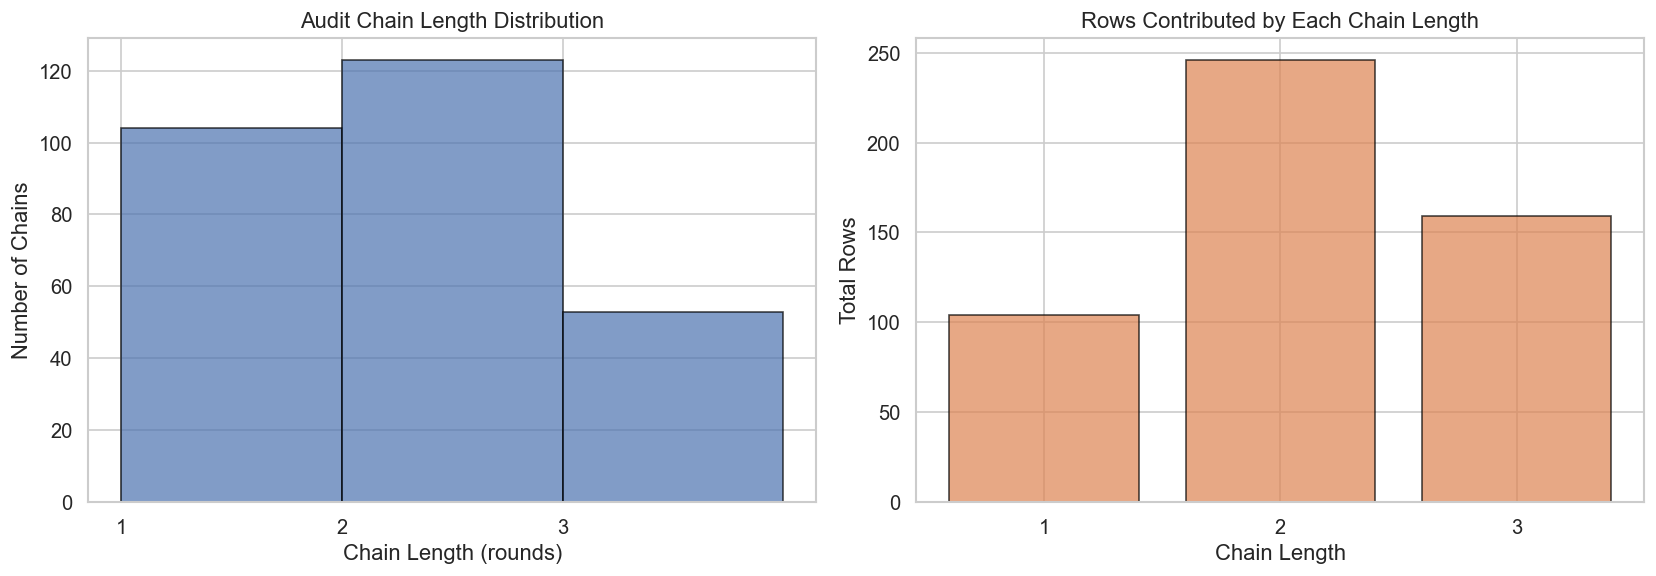

Saved: chain_distribution.png


In [12]:
# ─── Visualise chain length distribution ──────────────────────
if chains:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Chain length histogram
    axes[0].hist(chain_lengths, bins=range(1, max(chain_lengths) + 2),
                 edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0].set_xlabel('Chain Length (rounds)')
    axes[0].set_ylabel('Number of Chains')
    axes[0].set_title('Audit Chain Length Distribution')
    axes[0].set_xticks(range(1, max(chain_lengths) + 1))

    # Rows per chain length
    rows_per_length = defaultdict(int)
    for v in chains.values():
        rows_per_length[len(v)] += len(v)
    lengths = sorted(rows_per_length.keys())
    axes[1].bar(lengths, [rows_per_length[l] for l in lengths],
                edgecolor='black', alpha=0.7, color='#DD8452')
    axes[1].set_xlabel('Chain Length')
    axes[1].set_ylabel('Total Rows')
    axes[1].set_title('Rows Contributed by Each Chain Length')
    axes[1].set_xticks(lengths)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chain_distribution.png', bbox_inches='tight')
    plt.show()
    print("Saved: chain_distribution.png")

---
## Section 3 — Structural Schema Validation

This section implements a recursive schema validator that checks every row against the exact
nested structure specified in the generation prompt. Each violation is categorised by severity:

- **FATAL**: Missing required sections or wrong data types that would crash the runtime
- **ERROR**: Missing required fields within sections
- **WARNING**: Minor issues like missing optional fields or suspicious values

In [13]:
class SchemaValidator:
    """Recursive schema validator for AuditorAgent training rows."""

    def __init__(self):
        self.violations = []

    def reset(self):
        self.violations = []

    def add(self, severity: str, path: str, message: str):
        self.violations.append({"severity": severity, "path": path, "message": message})

    def check_type(self, value, expected_type, path: str, label: str):
        if not isinstance(value, expected_type):
            self.add("FATAL", path,
                     f"{label} expected {expected_type.__name__}, got {type(value).__name__}")
            return False
        return True

    def check_key_exists(self, d: dict, key: str, path: str, severity="ERROR"):
        if key not in d:
            self.add(severity, f"{path}.{key}", f"Missing required key '{key}'")
            return False
        return True

    def validate_contract_field(self, field: dict, path: str):
        """Validate a single frozen contract field object."""
        if not isinstance(field, dict):
            self.add("FATAL", path, f"Contract field must be dict, got {type(field).__name__}")
            return
        for subkey in CONTRACT_FIELD_SUBKEYS:
            if subkey not in field:
                self.add("ERROR", f"{path}.{subkey}", f"Missing contract sub-key '{subkey}'")
        if 'confirmed' in field and not isinstance(field['confirmed'], bool):
            self.add("WARNING", f"{path}.confirmed",
                     f"'confirmed' should be bool, got {type(field['confirmed']).__name__}")

    def validate_row(self, row: Dict) -> List[Dict]:
        """Run full validation on a single row. Returns list of violations."""
        self.reset()
        sid = row.get('sample_id', 'UNKNOWN')

        # ── Top-level keys ──
        required_top = {"sample_id", "dataset", "agent", "split",
                        "profile", "input_payload", "target_output", "metadata"}
        for key in required_top:
            self.check_key_exists(row, key, "root", "FATAL")

        # ── Profile ──
        profile = row.get('profile', {})
        if self.check_type(profile, dict, "profile", "profile"):
            for pk in ["domain", "projectclass", "capabilities", "complexitylevel",
                        "risklevel", "datasensitivity", "externalexposure"]:
                self.check_key_exists(profile, pk, "profile")
            if 'capabilities' in profile and not isinstance(profile['capabilities'], list):
                self.add("ERROR", "profile.capabilities", "Must be a list")

        # ── Input payload ──
        payload = row.get('input_payload', {})
        if self.check_type(payload, dict, "input_payload", "input_payload"):
            for pk in ["round", "frozenrequirementcontract", "requirements",
                        "acceptedexceptions", "issueledger", "revisionmemory",
                        "previousaudits", "reasonerreviews", "specialistsubplans",
                        "plan", "bestaudit"]:
                self.check_key_exists(payload, pk, "input_payload")

            # Round must be integer
            if 'round' in payload and not isinstance(payload['round'], int):
                self.add("ERROR", "input_payload.round",
                         f"Round must be int, got {type(payload['round']).__name__}")

            # ── Frozen requirement contract ──
            contract = payload.get('frozenrequirementcontract', {})
            if self.check_type(contract, dict, "frozenrequirementcontract", "contract"):
                for mf in MANDATORY_CONTRACT_FIELDS:
                    if self.check_key_exists(contract, mf, "frozenrequirementcontract"):
                        self.validate_contract_field(contract[mf],
                                                     f"frozenrequirementcontract.{mf}")

            # ── Requirements (must be dict of dicts, not arrays) ──
            reqs = payload.get('requirements', {})
            if self.check_type(reqs, dict, "requirements", "requirements"):
                for section in REQUIRED_REQ_SECTIONS:
                    if section in reqs:
                        if isinstance(reqs[section], list):
                            self.add("ERROR", f"requirements.{section}",
                                     "Must be dict, got list (arrays forbidden)")
                        elif not isinstance(reqs[section], dict):
                            self.add("WARNING", f"requirements.{section}",
                                     f"Expected dict, got {type(reqs[section]).__name__}")

            # ── Previous audits must be list ──
            prev = payload.get('previousaudits')
            if prev is not None and not isinstance(prev, list):
                self.add("ERROR", "input_payload.previousaudits", "Must be a list")

            # ── Plan ──
            plan = payload.get('plan', {})
            if self.check_type(plan, dict, "plan", "plan"):
                for pk in MANDATORY_PLAN_KEYS:
                    self.check_key_exists(plan, pk, "plan")
                if 'fixreport' in plan and not isinstance(plan['fixreport'], list):
                    self.add("ERROR", "plan.fixreport", "Must be a list")

        # ── Target output ──
        output = row.get('target_output', {})
        if self.check_type(output, dict, "target_output", "target_output"):
            for ok in MANDATORY_OUTPUT_KEYS:
                self.check_key_exists(output, ok, "target_output")

            # Rubric scores
            rubric = output.get('rubricscores', {})
            if self.check_type(rubric, dict, "rubricscores", "rubricscores"):
                for dim in RUBRIC_DIMENSIONS:
                    if self.check_key_exists(rubric, dim, "rubricscores"):
                        score = rubric[dim]
                        if not isinstance(score, (int, float)):
                            self.add("ERROR", f"rubricscores.{dim}",
                                     f"Must be numeric, got {type(score).__name__}")
                        elif not (0 <= score <= 10):
                            self.add("ERROR", f"rubricscores.{dim}",
                                     f"Out of range: {score} (must be 0-10)")

            # Issue updates structure
            for iu in output.get('issueupdates', []):
                if isinstance(iu, dict):
                    for ik in ['id', 'title', 'severity', 'status', 'detail']:
                        if ik not in iu:
                            self.add("ERROR", "issueupdates.item",
                                     f"Missing key '{ik}' in issue update")

            # Requirement conflicts structure
            for rc in output.get('requirementconflicts', []):
                if isinstance(rc, dict):
                    for rk in ['issueid', 'field', 'currentvalue',
                                'proposedvalue', 'exactreason', 'severity']:
                        if rk not in rc:
                            self.add("ERROR", "requirementconflicts.item",
                                     f"Missing key '{rk}' in conflict")

        # ── Metadata ──
        meta = row.get('metadata', {})
        if self.check_type(meta, dict, "metadata", "metadata"):
            for mk in ["schema_version", "case_type", "primary_flaw_family",
                        "secondary_flaw_families", "intended_severity_mix",
                        "generation_source"]:
                self.check_key_exists(meta, mk, "metadata")

        return self.violations


# ─── Run structural validation ─────────────────────────────────
if rows:
    validator = SchemaValidator()
    all_violations = {}
    violation_summary = Counter()
    rows_with_fatal = 0

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        violations = validator.validate_row(row)
        if violations:
            all_violations[sid] = violations
            for v in violations:
                violation_summary[v['severity']] += 1
            if any(v['severity'] == 'FATAL' for v in violations):
                rows_with_fatal += 1

    total_violations = sum(violation_summary.values())
    clean_rows = len(rows) - len(all_violations)

    print(f"\n{'='*60}")
    print(f"STRUCTURAL VALIDATION REPORT")
    print(f"{'='*60}")
    print(f"Total rows validated: {len(rows)}")
    print(f"Rows with violations: {len(all_violations)} ({len(all_violations)/len(rows)*100:.1f}%)")
    print(f"Rows with FATAL errors: {rows_with_fatal}")
    print(f"Clean rows: {clean_rows} ({clean_rows/len(rows)*100:.1f}%)")
    print(f"\nViolation breakdown:")
    for sev in ['FATAL', 'ERROR', 'WARNING']:
        count = violation_summary.get(sev, 0)
        print(f"  {sev}: {count}")

    # Most common violation paths
    path_counts = Counter()
    for sid, viols in all_violations.items():
        for v in viols:
            path_counts[v['path']] += 1

    print(f"\nTop 10 most violated paths:")
    for path, count in path_counts.most_common(10):
        print(f"  {path}: {count} occurrences")
else:
    all_violations = {}
    violation_summary = Counter()


STRUCTURAL VALIDATION REPORT
Total rows validated: 509
Rows with violations: 24 (4.7%)
Rows with FATAL errors: 0
Clean rows: 485 (95.3%)

Violation breakdown:
  FATAL: 0
  ERROR: 24

Top 10 most violated paths:
  plan.generatedat: 24 occurrences


---
## Section 4 — Enum & Value Domain Compliance

This section validates every categorical field against the allowed enum sets and detects
forbidden values that the generation prompt explicitly bans. It also checks for snake_case
key violations inside nested payloads where compact keys are required.

In [14]:
def find_snake_case_keys(obj: Any, path: str = "", results: list = None) -> List[str]:
    """Recursively find any keys containing underscores (snake_case) in nested objects."""
    if results is None:
        results = []
    if isinstance(obj, dict):
        for key in obj.keys():
            current_path = f"{path}.{key}" if path else key
            if '_' in key and key not in {'sample_id', 'input_payload',
                                           'target_output', '_line_num', '_chain_id'}:
                results.append(current_path)
            find_snake_case_keys(obj[key], current_path, results)
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            find_snake_case_keys(item, f"{path}[{i}]", results)
    return results


def validate_enums(row: Dict) -> List[Dict]:
    """Validate all enum fields against allowed sets."""
    issues = []
    sid = row.get('sample_id', 'UNKNOWN')
    profile = row.get('profile', {})
    contract = row.get('input_payload', {}).get('frozenrequirementcontract', {})
    output = row.get('target_output', {})
    meta = row.get('metadata', {})

    # ── Profile enums ──
    checks = [
        (profile.get('projectclass'), ALLOWED_PROJECT_CLASSES, 'profile.projectclass'),
        (profile.get('complexitylevel'), ALLOWED_COMPLEXITY, 'profile.complexitylevel'),
        (profile.get('risklevel'), ALLOWED_RISK, 'profile.risklevel'),
        (profile.get('datasensitivity'), ALLOWED_SENSITIVITY, 'profile.datasensitivity'),
        (profile.get('externalexposure'), ALLOWED_EXPOSURE, 'profile.externalexposure'),
    ]

    for value, allowed, path in checks:
        if value and value not in allowed:
            issues.append({"path": path, "value": value, "type": "invalid_enum"})

    # ── Profile capabilities ──
    for cap in profile.get('capabilities', []):
        if cap not in ALLOWED_CAPABILITIES:
            issues.append({"path": "profile.capabilities", "value": cap,
                           "type": "invalid_capability"})

    # ── Contract enum values match profile ──
    enum_fields = {
        'projectclass': ('projectclass', ALLOWED_PROJECT_CLASSES),
        'complexitylevel': ('complexitylevel', ALLOWED_COMPLEXITY),
        'risklevel': ('risklevel', ALLOWED_RISK),
        'datasensitivity': ('datasensitivity', ALLOWED_SENSITIVITY),
        'externalexposure': ('externalexposure', ALLOWED_EXPOSURE),
    }
    for field, (profile_key, allowed) in enum_fields.items():
        cval = contract.get(field, {}).get('value', '')
        pval = profile.get(profile_key, '')
        if cval and cval not in allowed:
            issues.append({"path": f"contract.{field}", "value": cval,
                           "type": "invalid_contract_enum"})
        if cval and pval and cval != pval:
            issues.append({"path": f"contract.{field}",
                           "value": f"contract='{cval}' vs profile='{pval}'",
                           "type": "contract_profile_mismatch"})

    # ── Issue severities and statuses ──
    for iu in output.get('issueupdates', []):
        if isinstance(iu, dict):
            sev = iu.get('severity', '')
            if sev and sev not in ALLOWED_SEVERITY:
                issues.append({"path": "issueupdates.severity", "value": sev,
                               "type": "invalid_severity"})
            status = iu.get('status', '')
            if status and status not in ALLOWED_STATUS:
                issues.append({"path": "issueupdates.status", "value": status,
                               "type": "invalid_status"})

    for rc in output.get('requirementconflicts', []):
        if isinstance(rc, dict):
            sev = rc.get('severity', '')
            if sev and sev not in ALLOWED_SEVERITY:
                issues.append({"path": "requirementconflicts.severity", "value": sev,
                               "type": "invalid_severity"})

    # ── Metadata enums ──
    ct = meta.get('case_type', '')
    if ct and ct not in ALLOWED_CASE_TYPE:
        issues.append({"path": "metadata.case_type", "value": ct, "type": "invalid_case_type"})

    pff = meta.get('primary_flaw_family', '')
    if pff and pff not in ALLOWED_FLAW_FAMILIES:
        issues.append({"path": "metadata.primary_flaw_family", "value": pff,
                       "type": "invalid_flaw_family"})

    for sf in meta.get('secondary_flaw_families', []):
        if sf not in ALLOWED_FLAW_FAMILIES:
            issues.append({"path": "metadata.secondary_flaw_families", "value": sf,
                           "type": "invalid_flaw_family"})

    # ── Forbidden value scan (deep scan) ──
    raw_str = json.dumps(row).lower()
    for forbidden in FORBIDDEN_VALUES:
        pattern = r'\b' + re.escape(forbidden) + r'\b'
        if re.search(pattern, raw_str):
            issues.append({"path": "global", "value": forbidden,
                           "type": "forbidden_value"})

    return issues


# ─── Run enum validation ──────────────────────────────────────
if rows:
    enum_results = {}
    snake_case_results = {}

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')

        # Enum check
        enum_issues = validate_enums(row)
        if enum_issues:
            enum_results[sid] = enum_issues

        # Snake-case key check (inside payload/output only)
        payload = row.get('input_payload', {})
        output = row.get('target_output', {})
        sc_keys = find_snake_case_keys(payload, "input_payload")
        sc_keys += find_snake_case_keys(output, "target_output")
        if sc_keys:
            snake_case_results[sid] = sc_keys

    print(f"\n{'='*60}")
    print(f"ENUM & VALUE DOMAIN REPORT")
    print(f"{'='*60}")
    print(f"Rows with enum violations: {len(enum_results)} ({len(enum_results)/len(rows)*100:.1f}%)")
    print(f"Rows with snake_case keys: {len(snake_case_results)} ({len(snake_case_results)/len(rows)*100:.1f}%)")

    # Breakdown by type
    type_counts = Counter()
    for sid, issues in enum_results.items():
        for iss in issues:
            type_counts[iss['type']] += 1
    print(f"\nViolation types:")
    for t, c in type_counts.most_common():
        print(f"  {t}: {c}")

    if snake_case_results:
        sc_key_counts = Counter()
        for sid, keys in snake_case_results.items():
            for k in keys:
                sc_key_counts[k] += 1
        print(f"\nTop snake_case key violations:")
        for k, c in sc_key_counts.most_common(10):
            print(f"  {k}: {c} rows")
else:
    enum_results = {}
    snake_case_results = {}


ENUM & VALUE DOMAIN REPORT
Rows with enum violations: 150 (29.5%)
Rows with snake_case keys: 284 (55.8%)

Violation types:
  forbidden_value: 153
  invalid_status: 6
  invalid_capability: 2

Top snake_case key violations:
  input_payload.revisionmemory.round_1: 218 rows
  input_payload.revisionmemory.changes_for_round_2: 174 rows
  input_payload.revisionmemory.round_2: 65 rows
  input_payload.revisionmemory.changes_for_round_3: 61 rows
  input_payload.requirements.confirmeddecisions.no_telemetry: 1 rows
  input_payload.revisionmemory.round_3: 1 rows
  input_payload.revisionmemory.changes_for_round_4: 1 rows


---
## Section 5 — Cross-Field Consistency Validation

This section checks the logical invariants that must hold across fields within each row:

1. **Conditional field rules**: `llmintegration` required when capabilities include `aillm`;
   `compliancecontext` required when risk/sensitivity thresholds are met
2. **First-pass vs revision-round invariants**: round number, previous audits, fix reports
3. **Issue-ID stability across rounds**: within chains
4. **Issue-detail template compliance**: strict format check
5. **Metadata-output agreement**: flaw families match actual issues

In [15]:
def validate_cross_field(row: Dict) -> List[Dict]:
    """Validate cross-field consistency rules."""
    issues = []
    profile = row.get('profile', {})
    payload = row.get('input_payload', {})
    output = row.get('target_output', {})
    meta = row.get('metadata', {})
    contract = payload.get('frozenrequirementcontract', {})
    round_num = payload.get('round', 1)
    case_type = meta.get('case_type', '')

    capabilities = profile.get('capabilities', [])
    risk = profile.get('risklevel', '')
    sensitivity = profile.get('datasensitivity', '')

    # ── 1. Conditional field: llmintegration ──
    if 'aillm' in capabilities:
        if 'llmintegration' not in contract:
            issues.append({"rule": "conditional_llm", "severity": "ERROR",
                           "detail": "capabilities includes 'aillm' but contract missing 'llmintegration'"})

    # ── 2. Conditional field: compliancecontext ──
    needs_compliance = (
        risk == 'high' or
        sensitivity in ('personal', 'financial', 'health', 'confidential') or
        'payments' in capabilities
    )
    if needs_compliance and 'compliancecontext' not in contract:
        issues.append({"rule": "conditional_compliance", "severity": "ERROR",
                       "detail": f"Risk={risk}, sensitivity={sensitivity} requires 'compliancecontext'"})

    # ── 3. First-pass invariants ──
    if case_type == 'first_pass':
        if round_num != 1:
            issues.append({"rule": "first_pass_round", "severity": "WARNING",
                           "detail": f"first_pass but round={round_num} (expected 1)"})
        prev = payload.get('previousaudits', [])
        if prev and len(prev) > 0:
            issues.append({"rule": "first_pass_prevaudits", "severity": "WARNING",
                           "detail": "first_pass should have empty previousaudits"})

    # ── 4. Revision-round invariants ──
    if case_type == 'revision_round':
        if round_num <= 1:
            issues.append({"rule": "revision_round_num", "severity": "ERROR",
                           "detail": f"revision_round but round={round_num} (expected > 1)"})
        prev = payload.get('previousaudits', [])
        if not prev or len(prev) == 0:
            issues.append({"rule": "revision_no_prevaudits", "severity": "ERROR",
                           "detail": "revision_round must have non-empty previousaudits"})
        ledger = payload.get('issueledger', {})
        if not ledger:
            issues.append({"rule": "revision_no_ledger", "severity": "ERROR",
                           "detail": "revision_round must have non-empty issueledger"})

        # Fix report should reference prior issues
        fixreport = payload.get('plan', {}).get('fixreport', [])
        if not fixreport:
            issues.append({"rule": "revision_no_fixreport", "severity": "WARNING",
                           "detail": "revision_round should have non-empty fixreport"})

        # Summary must contain progression language
        summary = output.get('summary', '')
        has_progression = any(pw in summary.lower() for pw in PROGRESSION_WORDS)
        if not has_progression:
            issues.append({"rule": "revision_no_progression", "severity": "ERROR",
                           "detail": f"revision_round summary must contain one of {PROGRESSION_WORDS}"})

        # At least one prior issue ID must reappear in issueupdates
        if ledger:
            ledger_ids = set(ledger.keys())
            update_ids = {iu.get('id', '') for iu in output.get('issueupdates', [])
                          if isinstance(iu, dict)}
            overlap = ledger_ids & update_ids
            if not overlap:
                issues.append({"rule": "revision_no_issue_reuse", "severity": "ERROR",
                               "detail": "No prior issue IDs reappear in issueupdates"})

    # ── 5. Issue-detail template compliance ──
    for iu in output.get('issueupdates', []):
        if isinstance(iu, dict):
            detail = iu.get('detail', '')
            if detail and not DETAIL_TEMPLATE_RE.match(detail):
                issues.append({"rule": "detail_template", "severity": "ERROR",
                               "detail": f"Issue {iu.get('id','?')}: detail does not start with "
                                         f"Fixed/Partially fixed/Unchanged/Newly introduced"})
            # Check for Evidence: and Impact: sections
            if detail:
                if 'Evidence:' not in detail and 'evidence:' not in detail.lower():
                    issues.append({"rule": "detail_no_evidence", "severity": "WARNING",
                                   "detail": f"Issue {iu.get('id','?')}: missing 'Evidence:' in detail"})
                if 'Impact:' not in detail and 'impact:' not in detail.lower():
                    issues.append({"rule": "detail_no_impact", "severity": "WARNING",
                                   "detail": f"Issue {iu.get('id','?')}: missing 'Impact:' in detail"})

    # ── 6. Metadata-output agreement ──
    pff = meta.get('primary_flaw_family', '')
    blocking = output.get('blockingissues', [])
    conflicts = output.get('requirementconflicts', [])
    issue_updates = output.get('issueupdates', [])

    if pff == 'none':
        if blocking:
            issues.append({"rule": "meta_none_but_blocking", "severity": "ERROR",
                           "detail": "primary_flaw_family='none' but blockingissues is non-empty"})
        unresolved_high = any(
            isinstance(iu, dict) and iu.get('status') != 'resolved'
            and iu.get('severity') in ('critical', 'high')
            for iu in issue_updates
        )
        if unresolved_high:
            issues.append({"rule": "meta_none_but_unresolved_high", "severity": "ERROR",
                           "detail": "primary_flaw_family='none' but has unresolved high/critical issues"})

    # intended_severity_mix must match actual issues
    intended_mix = set(meta.get('intended_severity_mix', []))
    actual_severities = {iu.get('severity') for iu in issue_updates
                         if isinstance(iu, dict) and iu.get('status') != 'resolved'}
    if 'critical' in intended_mix and 'critical' not in actual_severities:
        issues.append({"rule": "meta_mix_critical_missing", "severity": "WARNING",
                       "detail": "intended_severity_mix includes 'critical' but no unresolved critical issues"})

    # ── 7. Case type vs round consistency ──
    if case_type == 'first_pass' and round_num > 1:
        issues.append({"rule": "case_type_round_mismatch", "severity": "ERROR",
                       "detail": f"case_type=first_pass but round={round_num}"})
    if case_type == 'revision_round' and round_num == 1:
        issues.append({"rule": "case_type_round_mismatch", "severity": "ERROR",
                       "detail": f"case_type=revision_round but round=1"})

    return issues


# ─── Run cross-field validation ───────────────────────────────
if rows:
    crossfield_results = {}
    rule_counts = Counter()

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        issues = validate_cross_field(row)
        if issues:
            crossfield_results[sid] = issues
            for iss in issues:
                rule_counts[iss['rule']] += 1

    print(f"\n{'='*60}")
    print(f"CROSS-FIELD CONSISTENCY REPORT")
    print(f"{'='*60}")
    print(f"Rows with violations: {len(crossfield_results)} ({len(crossfield_results)/len(rows)*100:.1f}%)")
    print(f"\nRule violation counts:")
    for rule, count in rule_counts.most_common():
        print(f"  {rule}: {count}")
else:
    crossfield_results = {}


CROSS-FIELD CONSISTENCY REPORT
Rows with violations: 237 (46.6%)

Rule violation counts:
  revision_no_progression: 162
  conditional_compliance: 118
  conditional_llm: 4
  revision_no_fixreport: 2
  revision_no_issue_reuse: 2
  meta_mix_critical_missing: 2


---
## Section 6 — Score Calibration & Anti-Inflation Analysis

The runtime computes a final score using a weighted rubric formula with severity-based penalties.
This section independently verifies that rubric scores are calibrated correctly by:

1. **Recomputing** the base score and penalties from each row's rubric scores and issue updates
2. **Detecting anti-inflation violations** where scores are unrealistically high given plan quality
3. **Measuring plan richness** as a proxy for whether high scores are justified
4. **Identifying the "perfect row" proportion** (must be < 5%)

In [16]:
def compute_plan_richness(plan: Dict) -> Dict[str, Any]:
    """
    Compute richness metrics for plan sections.
    Returns word counts per section and aggregate specificity score.
    """
    rich_sections = [
        "executivesummary", "architectureoverview", "technologystack",
        "functionalfeaturemap", "systemcomponents", "workflows",
        "datamodel", "apidesign", "securityandcompliance",
        "deploymentandoperations", "observability", "costandscaling",
        "phasedimplementation", "developmentguidelines", "risksandtradeoffs"
    ]

    section_words = {}
    total_words = 0
    one_word_sections = 0

    for section in rich_sections:
        text = str(plan.get(section, ''))
        words = len(text.split())
        section_words[section] = words
        total_words += words
        if words <= 2:
            one_word_sections += 1

    # Specificity score: count technology-specific terms
    plan_text = ' '.join(str(plan.get(s, '')) for s in rich_sections).lower()
    tech_terms = [
        'kubernetes', 'k8s', 'docker', 'ecs', 'fargate', 'lambda', 'rds',
        'dynamodb', 'postgres', 'mongodb', 'redis', 'kafka', 'rabbitmq',
        'nginx', 'express', 'fastapi', 'django', 'spring', 'react', 'vue',
        'angular', 'flutter', 'swift', 'kotlin', 'terraform', 'helm',
        'argocd', 'jenkins', 'github actions', 'datadog', 'prometheus',
        'grafana', 'cloudwatch', 'tls', 'mtls', 'oauth', 'oidc', 'jwt',
        'cognito', 'auth0', 'okta', 'mfa', 'rbac', 'abac', 'waf',
        's3', 'cloudfront', 'alb', 'nlb', 'api gateway', 'sns', 'sqs',
        'openapi', 'graphql', 'grpc', 'rest', 'websocket', 'sse'
    ]
    tech_count = sum(1 for t in tech_terms if t in plan_text)

    return {
        "section_words": section_words,
        "total_words": total_words,
        "mean_words_per_section": total_words / max(len(rich_sections), 1),
        "one_word_sections": one_word_sections,
        "tech_term_count": tech_count,
        "specificity_score": min(10, tech_count * 0.8)  # Rough proxy
    }


def validate_score_calibration(row: Dict) -> List[Dict]:
    """Check score calibration rules."""
    issues = []
    output = row.get('target_output', {})
    plan = row.get('input_payload', {}).get('plan', {})
    profile = row.get('profile', {})
    rubric = output.get('rubricscores', {})

    if not rubric:
        return issues

    # ── Compute base score ──
    base_score = sum(
        rubric.get(dim, 0) * weight
        for dim, weight in RUBRIC_WEIGHTS.items()
    )

    # ── Compute penalty ──
    penalty = 0.0
    has_unresolved_critical = False
    for iu in output.get('issueupdates', []):
        if isinstance(iu, dict):
            status = str(iu.get('status', '')).lower()
            severity = str(iu.get('severity', '')).lower()
            if status == 'resolved':
                continue
            penalty += SEVERITY_PENALTIES.get(severity, 0)
            if severity == 'critical':
                has_unresolved_critical = True

    implied_score = max(0, min(10, base_score - penalty))

    # ── Plan richness ──
    richness = compute_plan_richness(plan)

    # ── Anti-inflation checks ──
    avg_rubric = np.mean([rubric.get(d, 0) for d in RUBRIC_DIMENSIONS])

    # Rule 1: All 10s check
    all_tens = all(rubric.get(d, 0) == 10 for d in RUBRIC_DIMENSIONS)
    if all_tens:
        issues.append({"rule": "all_tens", "severity": "WARNING",
                       "detail": "All rubric scores are 10 — verify plan is exceptionally strong"})

    # Rule 2: Architecture quality >= 9 requires non-thin plan
    aq = rubric.get('architecturequality', 0)
    if aq >= 9 and richness['mean_words_per_section'] < 15:
        issues.append({"rule": "arch_inflation", "severity": "ERROR",
                       "detail": f"architecturequality={aq} but mean section length is "
                                 f"{richness['mean_words_per_section']:.0f} words (thin plan)"})

    # Rule 3: Operability >= 9 requires concrete deployment detail
    op = rubric.get('operability', 0)
    deploy_words = richness['section_words'].get('deploymentandoperations', 0)
    obs_words = richness['section_words'].get('observability', 0)
    if op >= 9 and (deploy_words < 10 or obs_words < 5):
        issues.append({"rule": "ops_inflation", "severity": "ERROR",
                       "detail": f"operability={op} but deployment={deploy_words}w, "
                                 f"observability={obs_words}w"})

    # Rule 4: Security >= 9 for high-risk/sensitive systems needs concrete controls
    sec = rubric.get('security', 0)
    risk = profile.get('risklevel', '')
    sensitivity = profile.get('datasensitivity', '')
    sec_words = richness['section_words'].get('securityandcompliance', 0)
    if sec >= 9 and (risk == 'high' or sensitivity in ('health', 'financial', 'confidential')):
        if sec_words < 15:
            issues.append({"rule": "security_inflation", "severity": "ERROR",
                           "detail": f"security={sec} for {risk}/{sensitivity} system but "
                                     f"securityandcompliance only {sec_words} words"})

    # Rule 5: Blocking issues present but no rubric dimension materially reduced
    blocking = output.get('blockingissues', [])
    if blocking and all(rubric.get(d, 0) > 7 for d in RUBRIC_DIMENSIONS):
        issues.append({"rule": "blocking_no_reduction", "severity": "ERROR",
                       "detail": "Blocking issues present but no rubric dimension <= 7"})

    # Rule 6: High avg rubric but thin plan
    if avg_rubric > 8.0 and richness['one_word_sections'] >= 3:
        issues.append({"rule": "high_score_thin_plan", "severity": "ERROR",
                       "detail": f"Average rubric={avg_rubric:.1f} but "
                                 f"{richness['one_word_sections']} sections have <=2 words"})

    return issues, {
        "base_score": round(base_score, 2),
        "penalty": round(penalty, 2),
        "implied_score": round(implied_score, 2),
        "has_unresolved_critical": has_unresolved_critical,
        "avg_rubric": round(avg_rubric, 2),
        "richness": richness
    }


# ─── Run score calibration ────────────────────────────────────
if rows:
    calibration_results = {}
    calibration_data = []
    inflation_issues = Counter()

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        result = validate_score_calibration(row)
        cal_issues, cal_data = result
        cal_data['sample_id'] = sid
        calibration_data.append(cal_data)

        if cal_issues:
            calibration_results[sid] = cal_issues
            for ci in cal_issues:
                inflation_issues[ci['rule']] += 1

    cal_df = pd.DataFrame(calibration_data)

    # Perfect row count
    perfect_rows = sum(
        1 for row in rows
        if all(row.get('target_output', {}).get('rubricscores', {}).get(d, 0) >= 9
               for d in RUBRIC_DIMENSIONS)
        and not row.get('target_output', {}).get('blockingissues', [])
        and not row.get('target_output', {}).get('requirementconflicts', [])
    )

    print(f"\n{'='*60}")
    print(f"SCORE CALIBRATION & ANTI-INFLATION REPORT")
    print(f"{'='*60}")
    print(f"Rows with calibration issues: {len(calibration_results)} "
          f"({len(calibration_results)/len(rows)*100:.1f}%)")
    print(f"\nAnti-inflation rule violations:")
    for rule, count in inflation_issues.most_common():
        print(f"  {rule}: {count}")
    print(f"\nPerfect rows (all >=9, no blockers/conflicts): {perfect_rows} "
          f"({perfect_rows/len(rows)*100:.1f}%) — target: <5%")

    if len(cal_df) > 0:
        print(f"\nScore Statistics:")
        print(f"  Base score — mean: {cal_df['base_score'].mean():.2f}, "
              f"std: {cal_df['base_score'].std():.2f}")
        print(f"  Penalty — mean: {cal_df['penalty'].mean():.2f}, "
              f"max: {cal_df['penalty'].max():.2f}")
        print(f"  Implied score — mean: {cal_df['implied_score'].mean():.2f}, "
              f"std: {cal_df['implied_score'].std():.2f}")
else:
    calibration_results = {}
    cal_df = pd.DataFrame()


SCORE CALIBRATION & ANTI-INFLATION REPORT
Rows with calibration issues: 217 (42.6%)

Anti-inflation rule violations:
  arch_inflation: 192
  ops_inflation: 162
  high_score_thin_plan: 142
  security_inflation: 63
  all_tens: 57

Perfect rows (all >=9, no blockers/conflicts): 183 (36.0%) — target: <5%

Score Statistics:
  Base score — mean: 6.62, std: 2.62
  Penalty — mean: 0.73, max: 4.50
  Implied score — mean: 5.89, std: 3.26


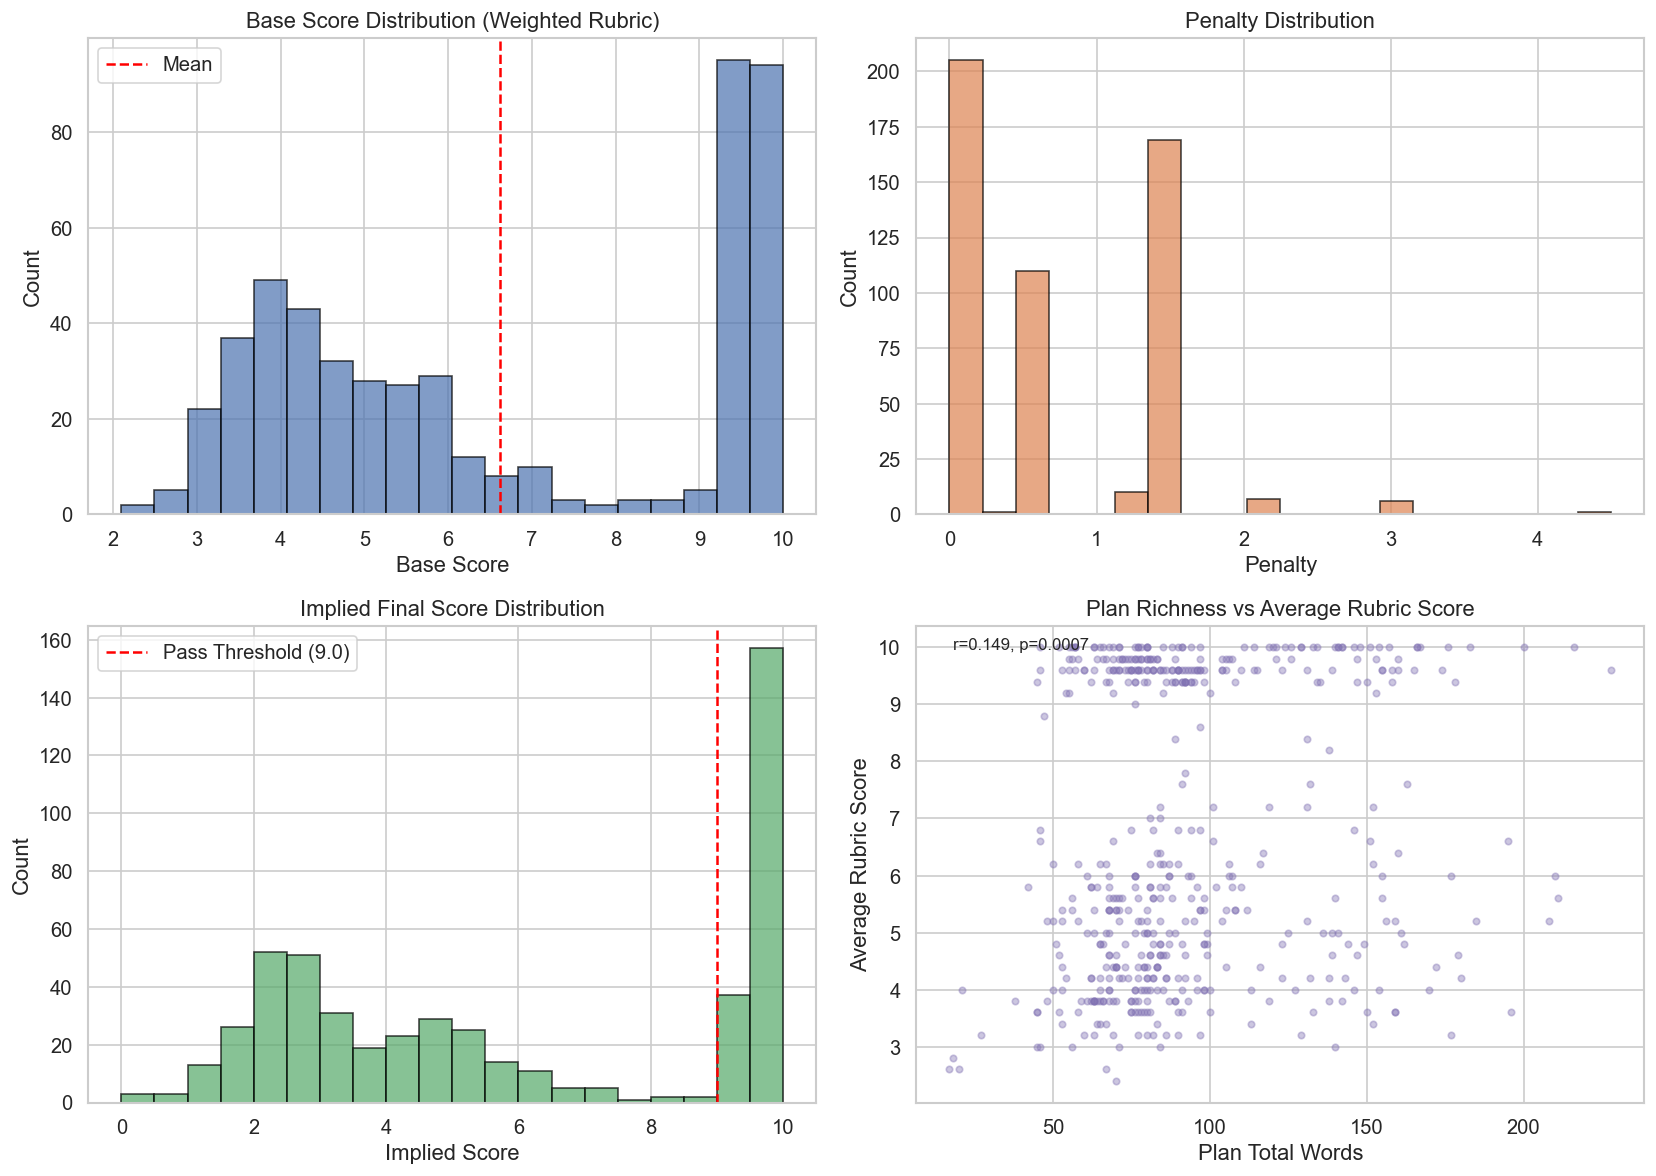

Saved: score_calibration.png


In [17]:
# ─── Calibration visualisations ───────────────────────────────
if len(cal_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Base score distribution
    axes[0, 0].hist(cal_df['base_score'], bins=20, edgecolor='black', alpha=0.7, color='#4C72B0')
    axes[0, 0].axvline(cal_df['base_score'].mean(), color='red', linestyle='--', label='Mean')
    axes[0, 0].set_xlabel('Base Score')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Base Score Distribution (Weighted Rubric)')
    axes[0, 0].legend()

    # 2. Penalty distribution
    axes[0, 1].hist(cal_df['penalty'], bins=20, edgecolor='black', alpha=0.7, color='#DD8452')
    axes[0, 1].set_xlabel('Penalty')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Penalty Distribution')

    # 3. Implied score distribution
    axes[1, 0].hist(cal_df['implied_score'], bins=20, edgecolor='black', alpha=0.7, color='#55A868')
    axes[1, 0].axvline(9.0, color='red', linestyle='--', label='Pass Threshold (9.0)')
    axes[1, 0].set_xlabel('Implied Score')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Implied Final Score Distribution')
    axes[1, 0].legend()

    # 4. Avg rubric vs plan richness (total words)
    richness_words = [cd.get('richness', {}).get('total_words', 0) for cd in calibration_data]
    axes[1, 1].scatter(richness_words, cal_df['avg_rubric'], alpha=0.4, s=15, color='#8172B3')
    axes[1, 1].set_xlabel('Plan Total Words')
    axes[1, 1].set_ylabel('Average Rubric Score')
    axes[1, 1].set_title('Plan Richness vs Average Rubric Score')

    # Add correlation
    if len(richness_words) > 2:
        r, p = stats.pearsonr(richness_words, cal_df['avg_rubric'])
        axes[1, 1].annotate(f'r={r:.3f}, p={p:.4f}', xy=(0.05, 0.95),
                            xycoords='axes fraction', fontsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'score_calibration.png', bbox_inches='tight')
    plt.show()
    print("Saved: score_calibration.png")

---
## Section 7 — Diversity & Coverage Analysis

Measures how well the dataset covers the operational surface of the runtime:
- Project-class distribution (Shannon entropy)
- Capability combination diversity (Jaccard distance)
- First-pass / revision-round ratio (target: 40/60)
- Flaw-family coverage
- Score distribution per rubric dimension

In [18]:
def compute_shannon_entropy(counts: Dict) -> float:
    """Compute Shannon entropy of a distribution."""
    total = sum(counts.values())
    if total == 0:
        return 0.0
    probs = [c / total for c in counts.values() if c > 0]
    return -sum(p * math.log2(p) for p in probs)


def compute_max_entropy(n_classes: int) -> float:
    """Maximum possible Shannon entropy for n_classes."""
    if n_classes <= 1:
        return 0.0
    return math.log2(n_classes)


if rows:
    # ── Project class distribution ──
    pc_counts = Counter(r.get('profile', {}).get('projectclass', 'MISSING') for r in rows)

    entropy_pc = compute_shannon_entropy(pc_counts)
    max_entropy_pc = compute_max_entropy(len(ALLOWED_PROJECT_CLASSES))
    normalised_entropy_pc = entropy_pc / max_entropy_pc if max_entropy_pc > 0 else 0

    print(f"{'='*60}")
    print(f"DIVERSITY & COVERAGE REPORT")
    print(f"{'='*60}")
    print(f"\n── Project Class Distribution ──")
    print(f"Entropy: {entropy_pc:.3f} / {max_entropy_pc:.3f} "
          f"(normalised: {normalised_entropy_pc:.3f})")
    print(f"Classes represented: {len(pc_counts)} / {len(ALLOWED_PROJECT_CLASSES)}")

    missing_classes = ALLOWED_PROJECT_CLASSES - set(pc_counts.keys())
    if missing_classes:
        print(f"Missing classes: {missing_classes}")

    under_represented = {k: v for k, v in pc_counts.items()
                         if v < len(rows) * 0.02}  # < 2%
    if under_represented:
        print(f"Under-represented (<2%): {under_represented}")

    over_represented = {k: v for k, v in pc_counts.items()
                        if v > len(rows) * 0.15}  # > 15%
    if over_represented:
        print(f"Over-represented (>15%): {over_represented}")

    # ── Capability combination diversity ──
    cap_combos = Counter(
        tuple(sorted(r.get('profile', {}).get('capabilities', [])))
        for r in rows
    )
    print(f"\n── Capability Combinations ──")
    print(f"Unique combinations: {len(cap_combos)}")
    print(f"Top 5 combinations:")
    for combo, count in cap_combos.most_common(5):
        print(f"  {combo}: {count}")

    # ── First-pass / revision ratio ──
    fp_count = sum(1 for r in rows
                   if r.get('metadata', {}).get('case_type') == 'first_pass')
    rr_count = sum(1 for r in rows
                   if r.get('metadata', {}).get('case_type') == 'revision_round')
    total_typed = fp_count + rr_count
    print(f"\n── Case Type Ratio ──")
    print(f"first_pass: {fp_count} ({fp_count/max(total_typed,1)*100:.1f}%) — target: 40%")
    print(f"revision_round: {rr_count} ({rr_count/max(total_typed,1)*100:.1f}%) — target: 60%")
    ratio_deviation = abs(fp_count / max(total_typed, 1) - 0.40)
    print(f"Deviation from target: {ratio_deviation*100:.1f}pp")

    # ── Flaw family coverage ──
    flaw_counts = Counter(
        r.get('metadata', {}).get('primary_flaw_family', 'MISSING')
        for r in rows
    )
    entropy_ff = compute_shannon_entropy(flaw_counts)
    max_entropy_ff = compute_max_entropy(len(ALLOWED_FLAW_FAMILIES))

    print(f"\n── Flaw Family Coverage ──")
    print(f"Entropy: {entropy_ff:.3f} / {max_entropy_ff:.3f}")
    print(f"Families represented: {len(flaw_counts)} / {len(ALLOWED_FLAW_FAMILIES)}")
    missing_flaws = ALLOWED_FLAW_FAMILIES - set(flaw_counts.keys())
    if missing_flaws:
        print(f"Missing flaw families: {missing_flaws}")

    # ── Severity distribution ──
    all_severities = []
    for r in rows:
        for iu in r.get('target_output', {}).get('issueupdates', []):
            if isinstance(iu, dict):
                all_severities.append(iu.get('severity', 'MISSING'))
    sev_counts = Counter(all_severities)
    print(f"\n── Issue Severity Distribution ──")
    for s in ['critical', 'high', 'medium', 'low']:
        print(f"  {s}: {sev_counts.get(s, 0)}")

DIVERSITY & COVERAGE REPORT

── Project Class Distribution ──
Entropy: 3.744 / 3.807 (normalised: 0.983)
Classes represented: 14 / 14

── Capability Combinations ──
Unique combinations: 62
Top 5 combinations:
  ('frontend',): 55
  ('backend',): 43
  ('auth', 'backend', 'frontend'): 33
  ('backend', 'data', 'frontend'): 32
  ('backend', 'frontend'): 28

── Case Type Ratio ──
first_pass: 226 (44.4%) — target: 40%
revision_round: 283 (55.6%) — target: 60%
Deviation from target: 4.4pp

── Flaw Family Coverage ──
Entropy: 2.386 / 3.459
Families represented: 10 / 11
Missing flaw families: {'regression'}

── Issue Severity Distribution ──
  critical: 352
  high: 252
  medium: 18
  low: 1


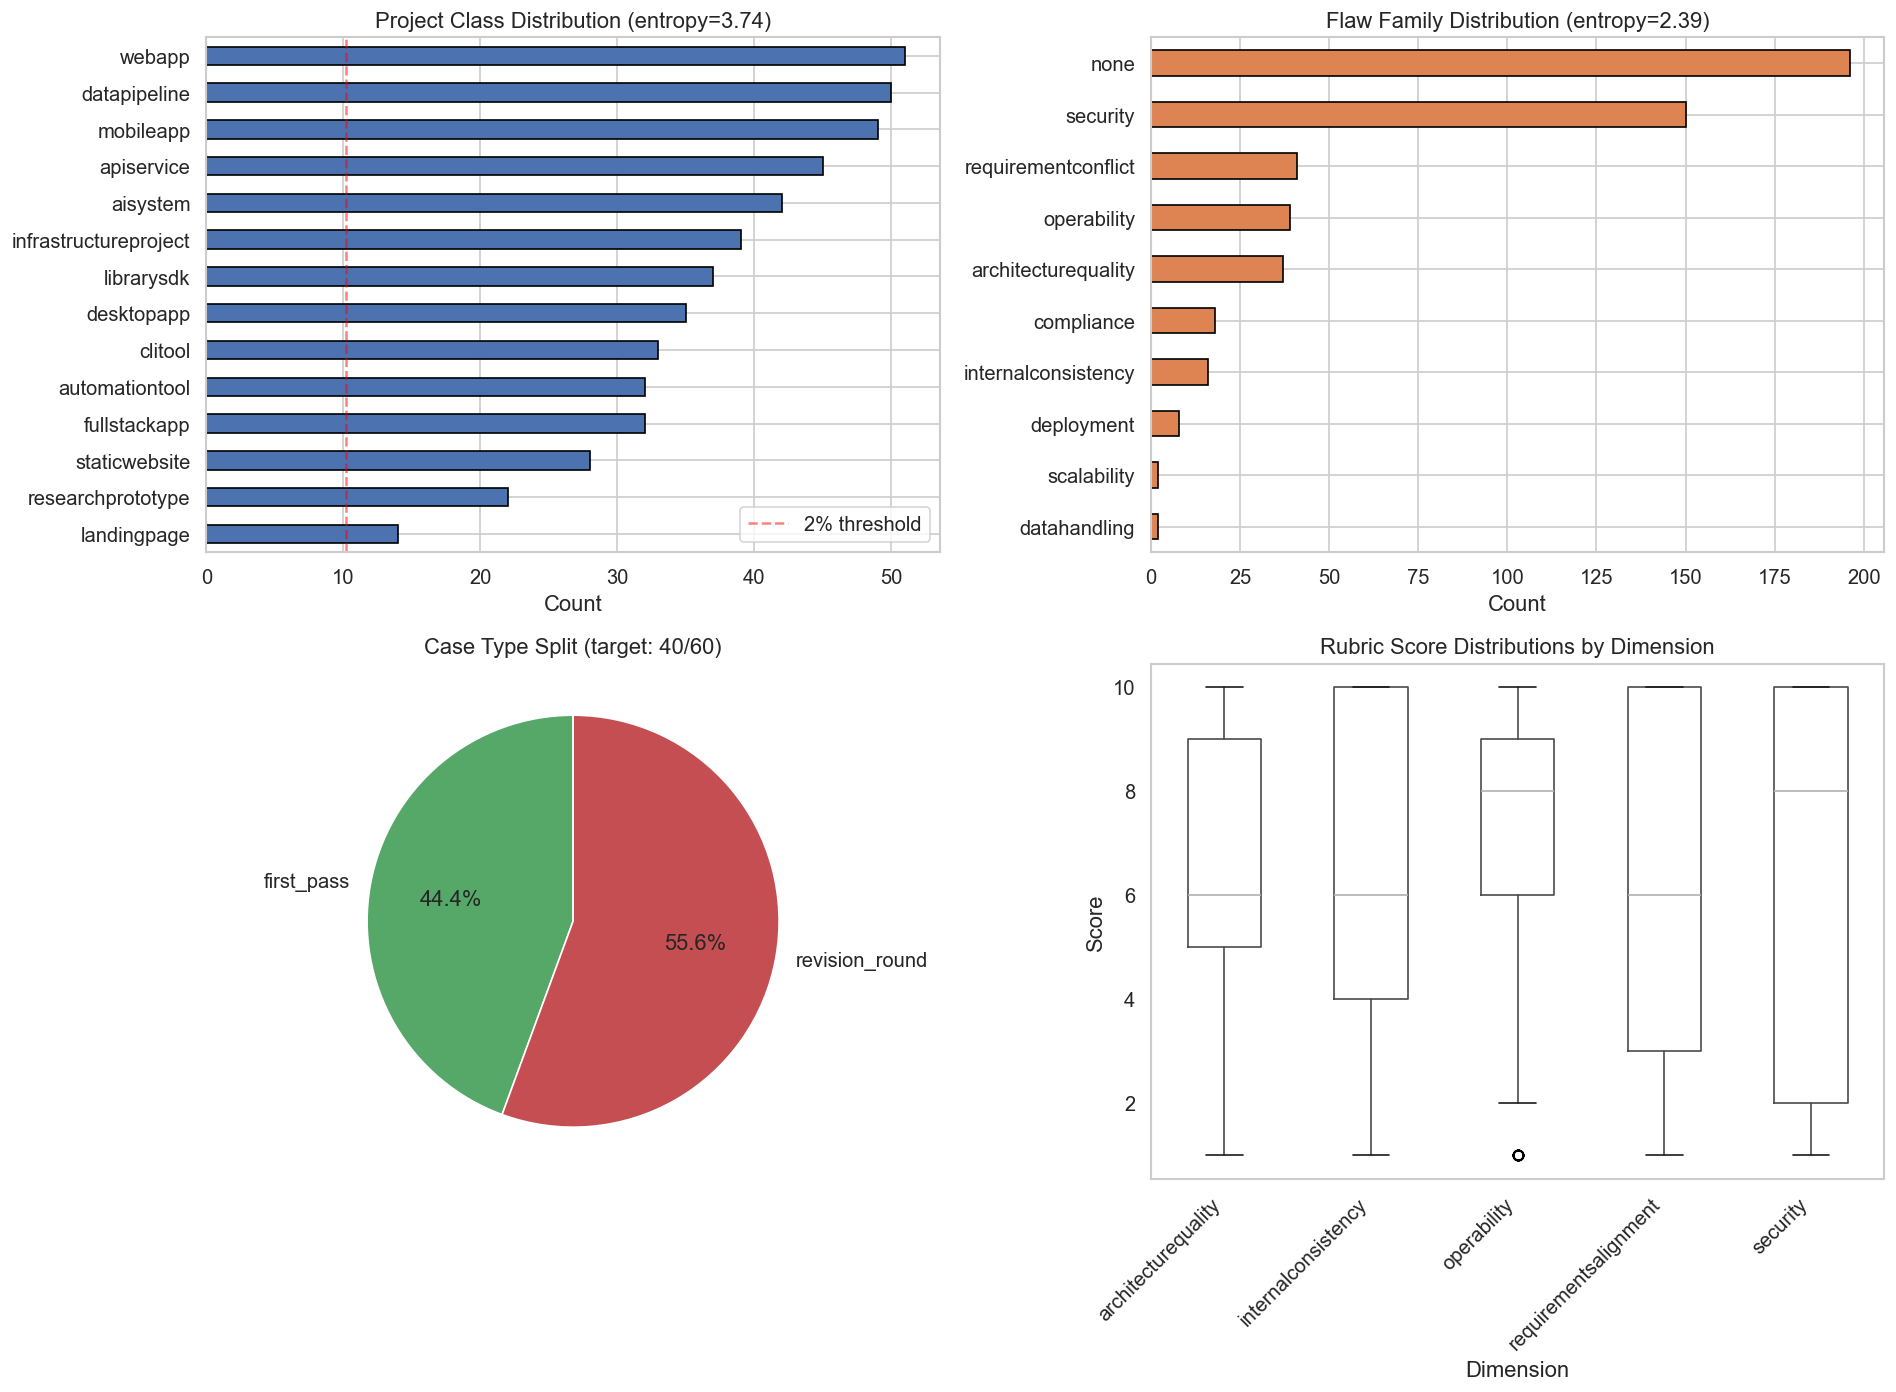

Saved: diversity_coverage.png


In [19]:
# ─── Diversity visualisations ─────────────────────────────────
if rows:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Project class distribution
    pc_series = pd.Series(pc_counts).sort_values(ascending=True)
    pc_series.plot(kind='barh', ax=axes[0, 0], color='#4C72B0', edgecolor='black')
    axes[0, 0].set_xlabel('Count')
    axes[0, 0].set_title(f'Project Class Distribution (entropy={entropy_pc:.2f})')
    axes[0, 0].axvline(len(rows) * 0.02, color='red', linestyle='--', alpha=0.5, label='2% threshold')
    axes[0, 0].legend()

    # 2. Flaw family distribution
    ff_series = pd.Series(flaw_counts).sort_values(ascending=True)
    ff_series.plot(kind='barh', ax=axes[0, 1], color='#DD8452', edgecolor='black')
    axes[0, 1].set_xlabel('Count')
    axes[0, 1].set_title(f'Flaw Family Distribution (entropy={entropy_ff:.2f})')

    # 3. Case type pie chart (actual vs target)
    axes[1, 0].pie([fp_count, rr_count], labels=['first_pass', 'revision_round'],
                    autopct='%1.1f%%', colors=['#55A868', '#C44E52'], startangle=90)
    axes[1, 0].set_title(f'Case Type Split (target: 40/60)')

    # 4. Rubric score distributions (box plots)
    rubric_data = []
    for r in rows:
        rub = r.get('target_output', {}).get('rubricscores', {})
        for dim in RUBRIC_DIMENSIONS:
            if dim in rub:
                rubric_data.append({"dimension": dim, "score": rub[dim]})
    if rubric_data:
        rub_df = pd.DataFrame(rubric_data)
        rub_df.boxplot(column='score', by='dimension', ax=axes[1, 1], grid=False)
        axes[1, 1].set_title('Rubric Score Distributions by Dimension')
        axes[1, 1].set_xlabel('Dimension')
        axes[1, 1].set_ylabel('Score')
        plt.sca(axes[1, 1])
        plt.xticks(rotation=45, ha='right')

    plt.suptitle('')  # Remove auto-generated suptitle from boxplot
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'diversity_coverage.png', bbox_inches='tight')
    plt.show()
    print("Saved: diversity_coverage.png")

---
## Section 8 — Duplication & Redundancy Detection

Three levels of deduplication, all **chain-aware**:

1. **Exact deduplication**: SHA-256 hash of row content (excluding metadata fields)
2. **Structural fingerprinting**: Feature vector based on categorical fields and score tuples
3. **Semantic similarity**: TF-IDF vectorisation of plan and audit text, cosine similarity with
   hierarchical clustering to identify near-duplicate clusters

Crucially, rows within the same audit chain are **excluded** from duplicate detection
because their shared contract content is intentional.

In [20]:
def get_content_hash(row: Dict) -> str:
    """Hash row content excluding non-content fields."""
    clean = {k: v for k, v in row.items()
             if k not in ('_line_num', '_chain_id', 'sample_id')}
    canonical = json.dumps(clean, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(canonical.encode()).hexdigest()


def get_structural_fingerprint(row: Dict) -> str:
    """Create feature fingerprint from categorical fields and score tuple."""
    profile = row.get('profile', {})
    rubric = row.get('target_output', {}).get('rubricscores', {})
    meta = row.get('metadata', {})
    payload = row.get('input_payload', {})

    parts = [
        profile.get('projectclass', ''),
        ','.join(sorted(profile.get('capabilities', []))),
        profile.get('risklevel', ''),
        profile.get('datasensitivity', ''),
        str(payload.get('round', '')),
        meta.get('case_type', ''),
        meta.get('primary_flaw_family', ''),
        ','.join(str(rubric.get(d, '')) for d in RUBRIC_DIMENSIONS),
    ]

    # Include sorted issue IDs
    issue_ids = sorted(
        iu.get('id', '') for iu in row.get('target_output', {}).get('issueupdates', [])
        if isinstance(iu, dict)
    )
    parts.append(','.join(issue_ids))

    return '|'.join(parts)


def extract_text_for_similarity(row: Dict) -> str:
    """Concatenate plan sections and audit text for TF-IDF vectorisation."""
    plan = row.get('input_payload', {}).get('plan', {})
    output = row.get('target_output', {})

    parts = []
    for key in MANDATORY_PLAN_KEYS:
        val = plan.get(key, '')
        if isinstance(val, str) and val:
            parts.append(val)
        elif isinstance(val, list):
            parts.append(' '.join(str(v) for v in val))

    parts.append(str(output.get('summary', '')))
    parts.append(' '.join(str(s) for s in output.get('strengths', [])))
    parts.append(' '.join(str(c) for c in output.get('concerns', [])))
    parts.append(' '.join(str(b) for b in output.get('blockingissues', [])))

    return ' '.join(parts)


# ─── Run deduplication analysis ───────────────────────────────
if rows:
    # 1. Exact hash deduplication
    hash_map = defaultdict(list)
    for row in rows:
        h = get_content_hash(row)
        hash_map[h].append(row.get('sample_id', 'UNKNOWN'))
    exact_dupes = {h: ids for h, ids in hash_map.items() if len(ids) > 1}

    # 2. Structural fingerprint deduplication (cross-chain only)
    fp_map = defaultdict(list)
    for row in rows:
        fp = get_structural_fingerprint(row)
        fp_map[fp].append((row.get('sample_id', 'UNKNOWN'), row.get('_chain_id', '')))

    # Filter: only flag if fingerprint matches are from DIFFERENT chains
    structural_dupes = {}
    for fp, entries in fp_map.items():
        chain_ids = set(e[1] for e in entries)
        if len(chain_ids) > 1:  # Same fingerprint across different chains = true dupe
            structural_dupes[fp] = entries

    print(f"\n{'='*60}")
    print(f"DUPLICATION & REDUNDANCY REPORT")
    print(f"{'='*60}")
    print(f"\n── Exact Duplicates ──")
    print(f"Duplicate groups: {len(exact_dupes)}")
    if exact_dupes:
        for h, ids in list(exact_dupes.items())[:5]:
            print(f"  {ids}")

    print(f"\n── Structural Duplicates (cross-chain) ──")
    print(f"Structural duplicate groups: {len(structural_dupes)}")
    for fp, entries in list(structural_dupes.items())[:3]:
        print(f"  IDs: {[e[0] for e in entries]}")

    # 3. Semantic similarity (TF-IDF + cosine, cross-chain)
    print(f"\n── Semantic Similarity Analysis ──")
    texts = []
    text_ids = []
    text_chains = []
    for row in rows:
        text = extract_text_for_similarity(row)
        texts.append(text)
        text_ids.append(row.get('sample_id', 'UNKNOWN'))
        text_chains.append(row.get('_chain_id', ''))

    if len(texts) > 1:
        vectorizer = TfidfVectorizer(max_features=5000, stop_words='english',
                                      ngram_range=(1, 2), min_df=2)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)

        # Find cross-chain near-duplicates (similarity > 0.92)
        SIMILARITY_THRESHOLD = 0.92
        near_dupes = []
        for i in range(len(rows)):
            for j in range(i + 1, len(rows)):
                if text_chains[i] != text_chains[j]:  # Different chains only
                    if sim_matrix[i, j] > SIMILARITY_THRESHOLD:
                        near_dupes.append({
                            "row_a": text_ids[i],
                            "row_b": text_ids[j],
                            "similarity": round(float(sim_matrix[i, j]), 4)
                        })

        print(f"Near-duplicate pairs (cosine > {SIMILARITY_THRESHOLD}, cross-chain): {len(near_dupes)}")
        if near_dupes:
            for nd in near_dupes[:10]:
                print(f"  {nd['row_a']} ↔ {nd['row_b']}: {nd['similarity']}")

        # Template repetition detection
        from collections import Counter
        sentence_counts = Counter()
        for text in texts:
            sentences = re.split(r'[.!?]+', text)
            for s in sentences:
                s = s.strip()
                if len(s.split()) > 8:  # Non-trivial sentences
                    sentence_counts[s.lower()] += 1
        repeated_sentences = {s: c for s, c in sentence_counts.items()
                              if c > len(rows) * 0.05}
        print(f"\n── Template Repetition ──")
        print(f"Sentences appearing in >5% of rows: {len(repeated_sentences)}")
        for s, c in sorted(repeated_sentences.items(), key=lambda x: -x[1])[:5]:
            print(f"  ({c}x) \"{s[:80]}...\"")
    else:
        sim_matrix = None
        near_dupes = []


DUPLICATION & REDUNDANCY REPORT

── Exact Duplicates ──
Duplicate groups: 0

── Structural Duplicates (cross-chain) ──
Structural duplicate groups: 1
  IDs: ['AUD-SYNC26-580', 'AUD-SYNC26-630']

── Semantic Similarity Analysis ──
Near-duplicate pairs (cosine > 0.92, cross-chain): 13
  AUD-SYNC26-279 ↔ AUD-SYNC26-428: 0.9669
  AUD-SYNC26-279 ↔ AUD-SYNC26-495: 0.9604
  AUD-SYNC26-280 ↔ AUD-SYNC26-429: 0.9718
  AUD-SYNC26-280 ↔ AUD-SYNC26-496: 0.9649
  AUD-SYNC26-281 ↔ AUD-SYNC26-430: 0.9768
  AUD-SYNC26-281 ↔ AUD-SYNC26-497: 0.966
  AUD-SYNC26-302 ↔ AUD-SYNC26-423: 0.9893
  AUD-SYNC26-302 ↔ AUD-SYNC26-471: 0.9322
  AUD-SYNC26-322 ↔ AUD-SYNC26-425: 0.966
  AUD-SYNC26-423 ↔ AUD-SYNC26-471: 0.9218

── Template Repetition ──
Sentences appearing in >5% of rows: 0


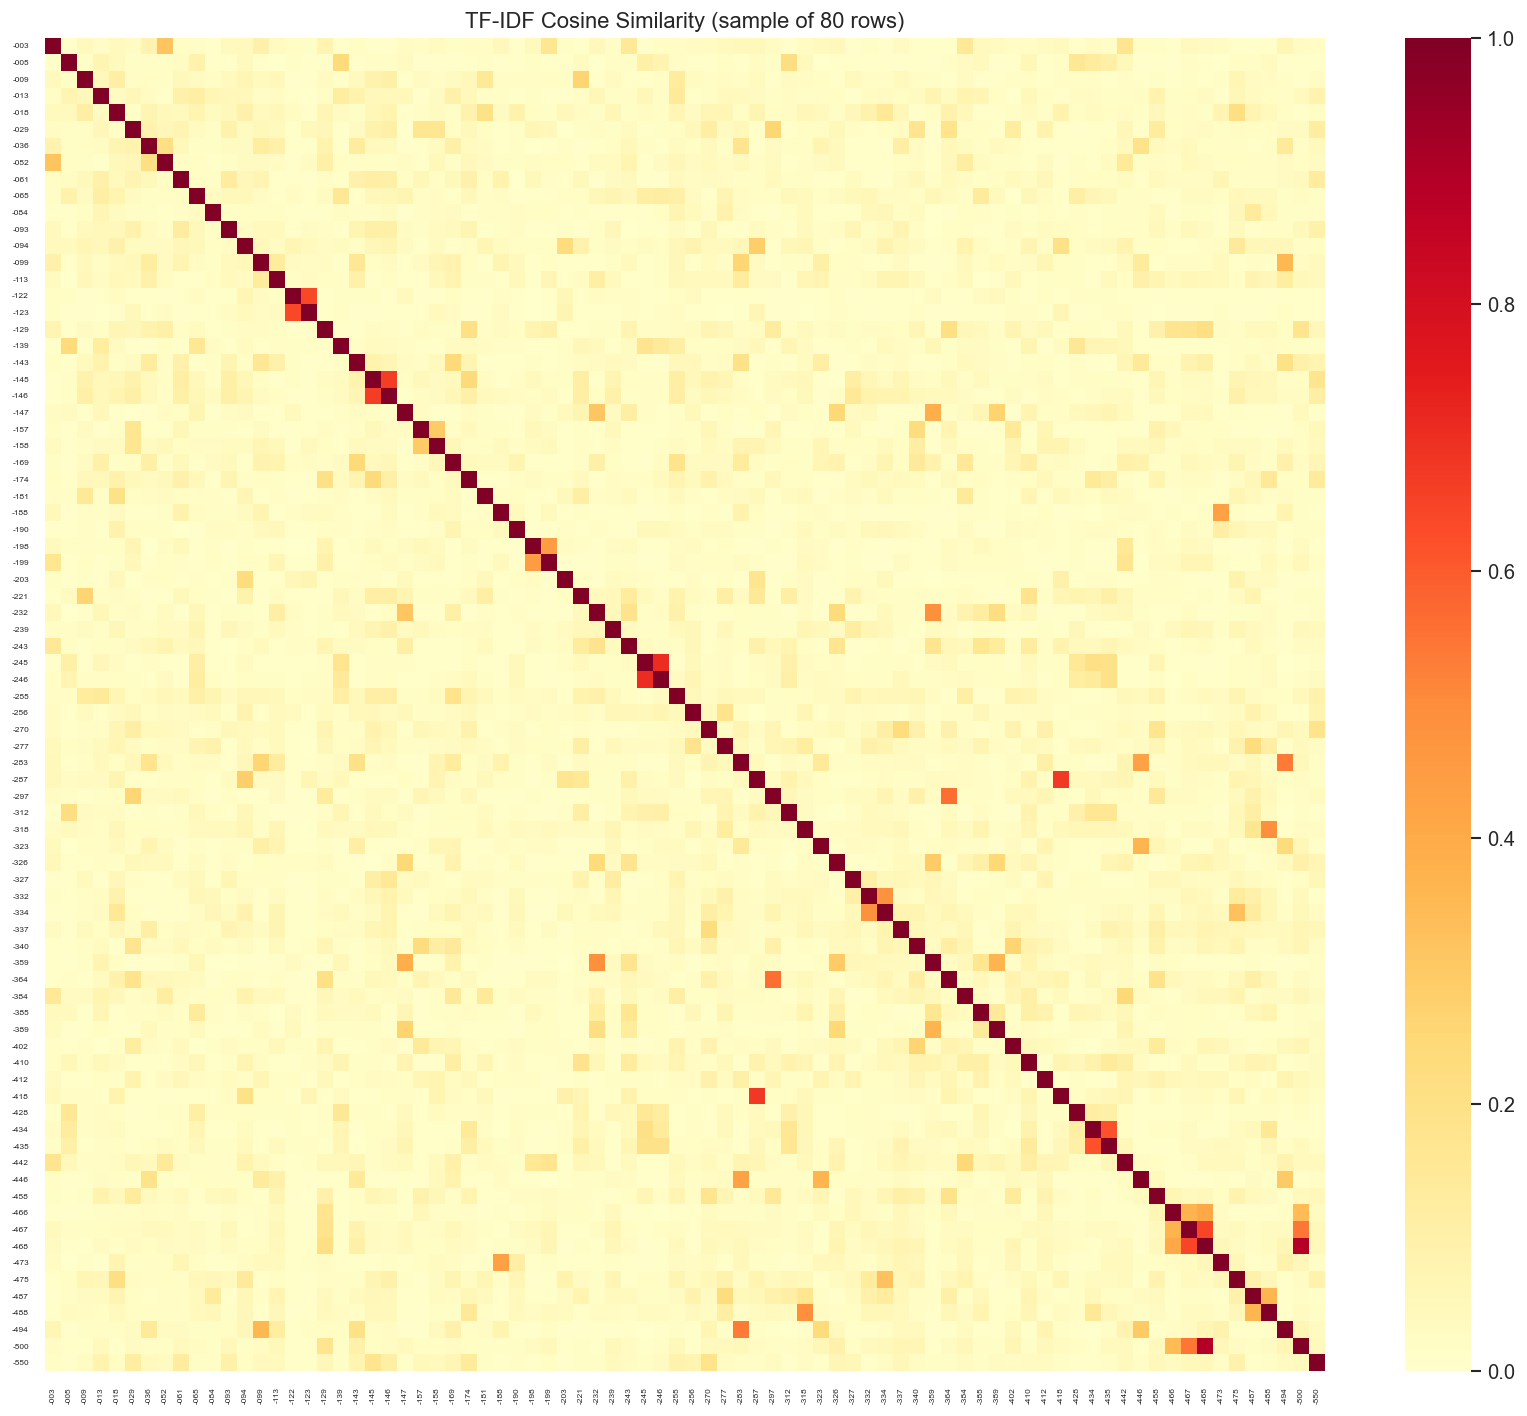

Saved: similarity_heatmap.png


In [21]:
# ─── Similarity heatmap (sampled for readability) ─────────────
if rows and sim_matrix is not None and len(rows) > 5:
    # Sample for visualization (full matrix would be unreadable for 750 rows)
    sample_size = min(80, len(rows))
    sample_indices = np.random.choice(len(rows), sample_size, replace=False)
    sample_indices.sort()

    sub_matrix = sim_matrix[np.ix_(sample_indices, sample_indices)]
    sub_ids = [text_ids[i][-4:] for i in sample_indices]  # Last 4 chars of ID

    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    sns.heatmap(sub_matrix, ax=ax, cmap='YlOrRd', vmin=0, vmax=1,
                xticklabels=sub_ids, yticklabels=sub_ids)
    ax.set_title(f'TF-IDF Cosine Similarity (sample of {sample_size} rows)')
    plt.xticks(fontsize=5, rotation=90)
    plt.yticks(fontsize=5)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'similarity_heatmap.png', bbox_inches='tight')
    plt.show()
    print("Saved: similarity_heatmap.png")

---
## Section 9 — Bias Detection

This section uses statistical methods to detect systematic biases that would cause the
fine-tuned model to behave unevenly across input types:

1. **Score-by-class bias**: ANOVA across project classes
2. **Rubric dimension correlation**: Pearson correlation matrix (should show independence)
3. **Technology concentration**: Gini coefficient of tech-name frequencies
4. **Length-score correlation**: Tests if longer plans get higher scores regardless of quality
5. **Sensitivity-level bias**: Whether certain data sensitivity levels systematically score higher

In [22]:
if rows:
    # ── Build analysis DataFrame ──
    analysis_rows = []
    for row in rows:
        profile = row.get('profile', {})
        rubric = row.get('target_output', {}).get('rubricscores', {})
        plan = row.get('input_payload', {}).get('plan', {})
        meta = row.get('metadata', {})

        plan_text = extract_text_for_similarity(row)

        analysis_rows.append({
            'sample_id': row.get('sample_id', ''),
            'projectclass': profile.get('projectclass', ''),
            'risklevel': profile.get('risklevel', ''),
            'datasensitivity': profile.get('datasensitivity', ''),
            'externalexposure': profile.get('externalexposure', ''),
            'complexitylevel': profile.get('complexitylevel', ''),
            'case_type': meta.get('case_type', ''),
            'primary_flaw': meta.get('primary_flaw_family', ''),
            'round': row.get('input_payload', {}).get('round', 0),
            'n_capabilities': len(profile.get('capabilities', [])),
            'plan_words': len(plan_text.split()),
            **{d: rubric.get(d, np.nan) for d in RUBRIC_DIMENSIONS},
            'avg_rubric': np.mean([rubric.get(d, 0) for d in RUBRIC_DIMENSIONS]),
            'n_issues': len(row.get('target_output', {}).get('issueupdates', [])),
            'n_blocking': len(row.get('target_output', {}).get('blockingissues', [])),
        })

    df = pd.DataFrame(analysis_rows)

    print(f"{'='*60}")
    print(f"BIAS DETECTION REPORT")
    print(f"{'='*60}")

    # ── 1. Score-by-class ANOVA ──
    print(f"\n── Score-by-Class Bias (ANOVA) ──")
    classes_with_data = [cls for cls in df['projectclass'].unique()
                         if len(df[df['projectclass'] == cls]) >= 3]

    if len(classes_with_data) >= 2:
        groups = [df[df['projectclass'] == cls]['avg_rubric'].values
                  for cls in classes_with_data]
        f_stat, p_value = stats.f_oneway(*groups)
        print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  ⚠ Significant score-by-class bias detected (p < 0.05)")
            class_means = df.groupby('projectclass')['avg_rubric'].mean().sort_values()
            print(f"  Lowest avg: {class_means.index[0]} ({class_means.iloc[0]:.2f})")
            print(f"  Highest avg: {class_means.index[-1]} ({class_means.iloc[-1]:.2f})")
        else:
            print("  ✓ No significant score-by-class bias")
    else:
        print("  Insufficient class diversity for ANOVA")

    # ── 2. Rubric dimension correlation ──
    print(f"\n── Rubric Dimension Correlation ──")
    rubric_cols = [d for d in RUBRIC_DIMENSIONS if d in df.columns]
    if len(rubric_cols) >= 2:
        corr_matrix = df[rubric_cols].corr()
        # Flag high correlations (should show independence)
        for i in range(len(rubric_cols)):
            for j in range(i + 1, len(rubric_cols)):
                r = corr_matrix.iloc[i, j]
                if abs(r) > 0.85:
                    print(f"  ⚠ High correlation: {rubric_cols[i]} ↔ {rubric_cols[j]}: r={r:.3f}")
        max_off_diag = corr_matrix.where(
            ~np.eye(len(rubric_cols), dtype=bool)
        ).abs().max().max()
        print(f"  Max off-diagonal |r|: {max_off_diag:.3f}")
        if max_off_diag < 0.85:
            print("  ✓ Rubric dimensions show reasonable independence")

    # ── 3. Length-score correlation ──
    print(f"\n── Length-Score Bias ──")
    if len(df) > 5:
        r_len, p_len = stats.pearsonr(df['plan_words'], df['avg_rubric'])
        print(f"Pearson r (plan_words vs avg_rubric): {r_len:.3f}, p={p_len:.4f}")
        if abs(r_len) > 0.5:
            print("  ⚠ Moderate-to-strong length-score bias detected")
        else:
            print("  ✓ No strong length-score bias")

    # ── 4. Technology concentration (Gini coefficient) ──
    print(f"\n── Technology Concentration ──")
    all_plan_text = ' '.join(
        extract_text_for_similarity(r).lower() for r in rows
    )
    tech_terms_found = Counter()
    common_techs = [
        'react', 'node.js', 'express', 'postgresql', 'python', 'django',
        'fastapi', 'flask', 'go', 'rust', 'java', 'spring', 'kotlin',
        'swift', 'flutter', 'vue', 'angular', 'svelte', 'next.js',
        'aws', 'gcp', 'azure', 'kubernetes', 'docker', 'terraform',
        'firebase', 'supabase', 'mongodb', 'redis', 'kafka', 'mysql',
        'sqlite', 'dynamodb', 'snowflake', 'airflow', 'spark',
        'datadog', 'prometheus', 'grafana', 'cloudwatch', 'sentry'
    ]
    for tech in common_techs:
        count = all_plan_text.count(tech)
        if count > 0:
            tech_terms_found[tech] = count

    if tech_terms_found:
        vals = sorted(tech_terms_found.values())
        n = len(vals)
        if n > 0:
            cumsum = np.cumsum(vals)
            gini = 1 - 2 * sum(cumsum) / (n * sum(vals)) + 1 / n
            print(f"Technologies mentioned: {len(tech_terms_found)}")
            print(f"Gini coefficient: {gini:.3f} (0=equal, 1=concentrated)")
            print(f"Top 5 technologies:")
            for tech, count in tech_terms_found.most_common(5):
                print(f"  {tech}: {count}")

    # ── 5. Sensitivity-level bias ──
    print(f"\n── Data Sensitivity Level Bias ──")
    sens_groups = df.groupby('datasensitivity')['avg_rubric'].agg(['mean', 'count'])
    print(sens_groups.to_string())
    if len(sens_groups) >= 2:
        sens_values = [df[df['datasensitivity'] == s]['avg_rubric'].values
                       for s in sens_groups.index if len(df[df['datasensitivity'] == s]) >= 3]
        if len(sens_values) >= 2:
            f_s, p_s = stats.f_oneway(*sens_values)
            print(f"ANOVA: F={f_s:.3f}, p={p_s:.4f}")

BIAS DETECTION REPORT

── Score-by-Class Bias (ANOVA) ──
F-statistic: 0.326, p-value: 0.9880
  ✓ No significant score-by-class bias

── Rubric Dimension Correlation ──
  ⚠ High correlation: requirementsalignment ↔ internalconsistency: r=0.929
  ⚠ High correlation: architecturequality ↔ internalconsistency: r=0.884
  Max off-diagonal |r|: 0.929

── Length-Score Bias ──
Pearson r (plan_words vs avg_rubric): 0.145, p=0.0011
  ✓ No strong length-score bias

── Technology Concentration ──
Technologies mentioned: 39
Gini coefficient: 0.543 (0=equal, 1=concentrated)
Top 5 technologies:
  go: 629
  aws: 597
  react: 374
  python: 306
  postgresql: 186

── Data Sensitivity Level Bias ──
                     mean  count
datasensitivity                 
confidential     6.640678     59
financial        6.501370     73
health           6.187234     47
internal         6.759748    159
none             6.934000    100
personal         6.777465     71
ANOVA: F=0.671, p=0.6457


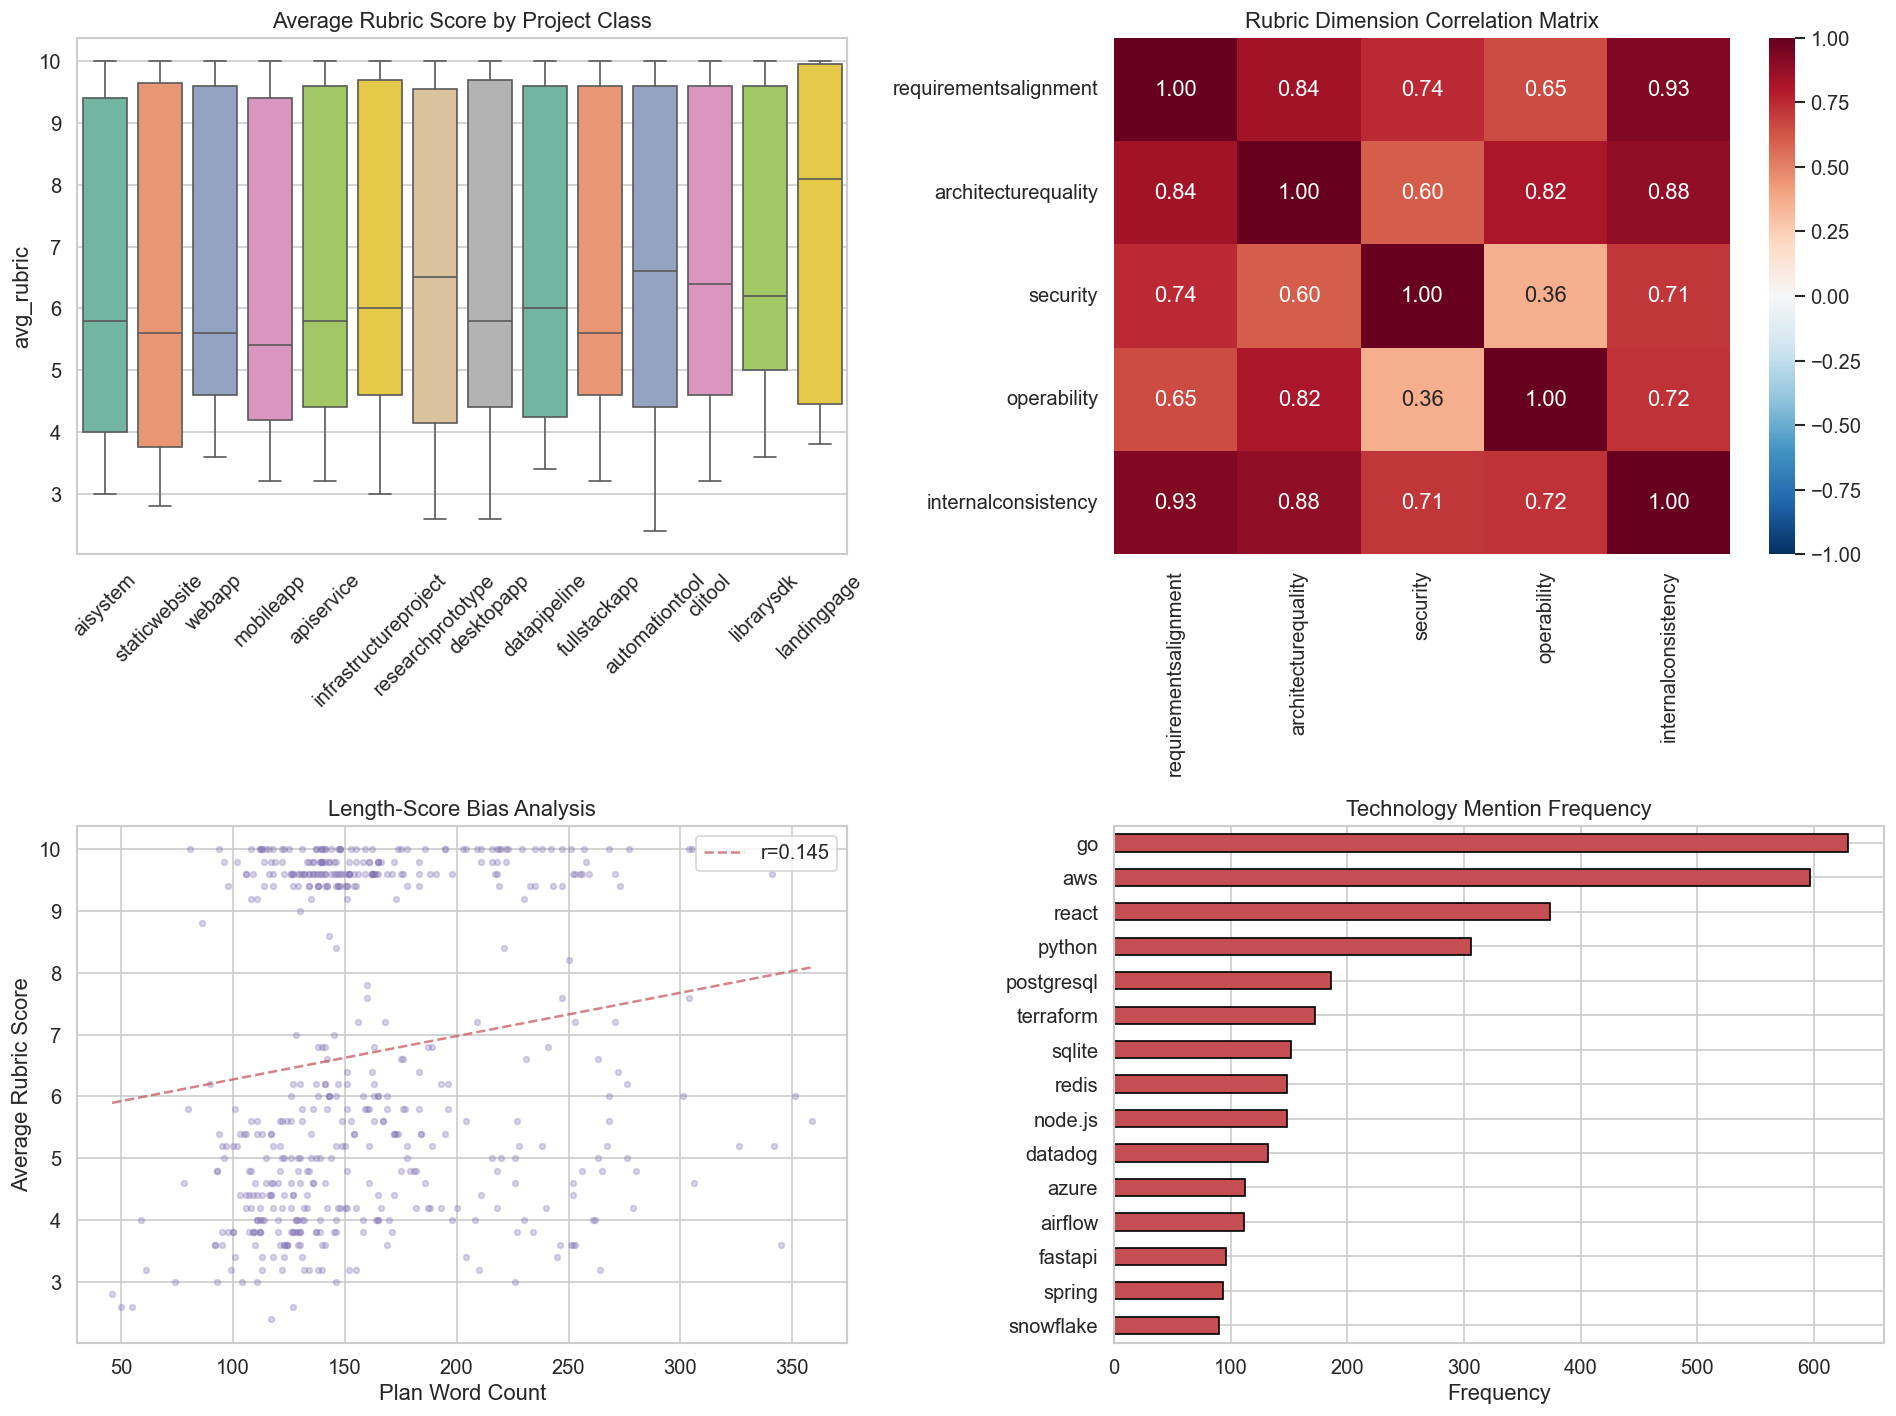

Saved: bias_analysis.png


In [24]:
# ─── Bias visualisations ─────────────────────────────────────
if rows and len(df) > 5:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Score by project class (box plot)
    class_order = df.groupby('projectclass')['avg_rubric'].mean().sort_values().index
    if len(class_order) > 1:
        sns.boxplot(data=df, x='projectclass', y='avg_rubric', order=class_order,
                    ax=axes[0, 0], palette='Set2')
        axes[0, 0].set_title('Average Rubric Score by Project Class')
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].set_xlabel('')

    # 2. Rubric correlation heatmap
    if len(rubric_cols) >= 2:
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, ax=axes[0, 1], vmin=-1, vmax=1)
        axes[0, 1].set_title('Rubric Dimension Correlation Matrix')

    # 3. Plan words vs score scatter
    axes[1, 0].scatter(df['plan_words'], df['avg_rubric'], alpha=0.3, s=12, c='#8172B3')
    z = np.polyfit(df['plan_words'], df['avg_rubric'], 1)
    p_fit = np.poly1d(z)
    x_line = np.linspace(df['plan_words'].min(), df['plan_words'].max(), 100)
    axes[1, 0].plot(x_line, p_fit(x_line), 'r--', alpha=0.7, label=f'r={r_len:.3f}')
    axes[1, 0].set_xlabel('Plan Word Count')
    axes[1, 0].set_ylabel('Average Rubric Score')
    axes[1, 0].set_title('Length-Score Bias Analysis')
    axes[1, 0].legend()

    # 4. Technology frequency bar chart
    if tech_terms_found:
        top_techs = dict(tech_terms_found.most_common(15))
        tech_s = pd.Series(top_techs).sort_values()
        tech_s.plot(kind='barh', ax=axes[1, 1], color='#C44E52', edgecolor='black')
        axes[1, 1].set_xlabel('Frequency')
        axes[1, 1].set_title('Technology Mention Frequency')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'bias_analysis.png', bbox_inches='tight')
    plt.show()
    print("Saved: bias_analysis.png")

---
## Section 10 — Chain Progression Validation

For multi-round audit chains, validate the temporal consistency:
- Issue IDs remain stable across rounds
- Resolved issues don't reappear without explanation
- Score trajectories are plausible
- Fix reports reference the correct prior issue IDs

In [25]:
def validate_chain_progression(chain: List[Dict]) -> List[Dict]:
    """Validate temporal consistency within an audit chain."""
    issues = []
    if len(chain) < 2:
        return issues

    for i in range(1, len(chain)):
        prev_row = chain[i - 1]
        curr_row = chain[i]

        prev_sid = prev_row.get('sample_id', '?')
        curr_sid = curr_row.get('sample_id', '?')
        prev_round = prev_row.get('input_payload', {}).get('round', 0)
        curr_round = curr_row.get('input_payload', {}).get('round', 0)

        # Round numbers should be sequential
        if curr_round != prev_round + 1:
            issues.append({
                "chain_step": f"{prev_sid} -> {curr_sid}",
                "rule": "round_sequence",
                "detail": f"Rounds {prev_round} -> {curr_round} (expected {prev_round + 1})"
            })

        # Previous issues that were resolved should not reappear as unresolved
        prev_updates = prev_row.get('target_output', {}).get('issueupdates', [])
        curr_updates = curr_row.get('target_output', {}).get('issueupdates', [])

        prev_resolved = {iu.get('id') for iu in prev_updates
                          if isinstance(iu, dict) and iu.get('status') == 'resolved'}
        curr_unresolved = {iu.get('id') for iu in curr_updates
                           if isinstance(iu, dict) and iu.get('status') in ('unresolved', 'new')}

        zombie_issues = prev_resolved & curr_unresolved
        if zombie_issues:
            issues.append({
                "chain_step": f"{prev_sid} -> {curr_sid}",
                "rule": "zombie_issue",
                "detail": f"Issues resolved in round {prev_round} reappear unresolved: {zombie_issues}"
            })

        # Score trajectory plausibility
        prev_rubric = prev_row.get('target_output', {}).get('rubricscores', {})
        curr_rubric = curr_row.get('target_output', {}).get('rubricscores', {})
        if prev_rubric and curr_rubric:
            prev_avg = np.mean([prev_rubric.get(d, 0) for d in RUBRIC_DIMENSIONS])
            curr_avg = np.mean([curr_rubric.get(d, 0) for d in RUBRIC_DIMENSIONS])

            # Large jumps without substantial plan changes are suspicious
            jump = curr_avg - prev_avg
            if abs(jump) > 4:
                issues.append({
                    "chain_step": f"{prev_sid} -> {curr_sid}",
                    "rule": "score_jump",
                    "detail": f"Score jump of {jump:+.1f} (from {prev_avg:.1f} to {curr_avg:.1f})"
                })

        # Fix report should reference prior issue IDs
        curr_fix = curr_row.get('input_payload', {}).get('plan', {}).get('fixreport', [])
        curr_ledger = curr_row.get('input_payload', {}).get('issueledger', {})
        if curr_fix and curr_ledger:
            fix_ids = {f.get('issueid', '') for f in curr_fix if isinstance(f, dict)}
            ledger_ids = set(curr_ledger.keys())
            orphan_fixes = fix_ids - ledger_ids
            if orphan_fixes:
                issues.append({
                    "chain_step": f"{prev_sid} -> {curr_sid}",
                    "rule": "orphan_fix",
                    "detail": f"Fix report references issue IDs not in ledger: {orphan_fixes}"
                })

    return issues


# ─── Run chain progression validation ─────────────────────────
if chains:
    chain_issues = {}
    chain_rule_counts = Counter()

    for chain_id, chain_rows in chains.items():
        if len(chain_rows) > 1:
            prog_issues = validate_chain_progression(chain_rows)
            if prog_issues:
                chain_issues[chain_id] = prog_issues
                for pi in prog_issues:
                    chain_rule_counts[pi['rule']] += 1

    print(f"\n{'='*60}")
    print(f"CHAIN PROGRESSION VALIDATION REPORT")
    print(f"{'='*60}")
    multi_chains_count = sum(1 for v in chains.values() if len(v) > 1)
    print(f"Multi-round chains validated: {multi_chains_count}")
    print(f"Chains with progression issues: {len(chain_issues)}")
    print(f"\nRule violation counts:")
    for rule, count in chain_rule_counts.most_common():
        print(f"  {rule}: {count}")


CHAIN PROGRESSION VALIDATION REPORT
Multi-round chains validated: 176
Chains with progression issues: 105

Rule violation counts:
  score_jump: 105


---
## Section 11 — Missed Issue Detection (Proxy Accuracy)

Scans for cases where the plan deviates from the frozen contract but the auditor fails to
raise a corresponding issue. This is a proxy for audit accuracy — it measures systematic
blind spots in the training data.

In [26]:
def detect_missed_issues(row: Dict) -> List[Dict]:
    """
    Compare plan content against contract fields to find deviations
    not caught by the audit output.
    """
    missed = []
    contract = row.get('input_payload', {}).get('frozenrequirementcontract', {})
    plan = row.get('input_payload', {}).get('plan', {})
    output = row.get('target_output', {})

    # Build set of fields already flagged in requirement conflicts
    flagged_fields = {rc.get('field', '') for rc in output.get('requirementconflicts', [])
                      if isinstance(rc, dict)}

    # Map contract fields to plan sections for cross-reference
    field_plan_map = {
        'observabilitybaseline': ('observability', None),
        'frontendstack': ('technologystack', None),
        'backendstack': ('technologystack', 'architectureoverview'),
        'dataplatform': ('technologystack', 'datamodel'),
        'hostingtarget': ('deploymentandoperations', None),
        'securitybaseline': ('securityandcompliance', None),
    }

    for field, plan_sections in field_plan_map.items():
        if field in flagged_fields:
            continue  # Already flagged

        contract_value = contract.get(field, {}).get('value', '').lower().strip()
        if not contract_value:
            continue

        # Check if the contract value appears in the relevant plan sections
        plan_text_parts = []
        if isinstance(plan_sections, tuple):
            for ps in plan_sections:
                if ps:
                    plan_text_parts.append(str(plan.get(ps, '')).lower())
        else:
            plan_text_parts.append(str(plan.get(plan_sections, '')).lower())

        plan_text = ' '.join(plan_text_parts)

        # Simple keyword containment check
        # Extract key terms from contract value
        contract_terms = [t.strip() for t in contract_value.split()
                          if len(t.strip()) > 2]

        if not contract_terms:
            continue

        # Check if at least one significant contract term appears in plan
        matches = sum(1 for t in contract_terms if t in plan_text)
        match_ratio = matches / len(contract_terms)

        if match_ratio < 0.3:  # Less than 30% of terms match
            missed.append({
                "field": field,
                "contract_value": contract_value,
                "plan_sections_checked": plan_sections,
                "match_ratio": round(match_ratio, 2)
            })

    return missed


# ─── Run missed issue detection ───────────────────────────────
if rows:
    missed_results = {}
    missed_field_counts = Counter()

    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')
        missed = detect_missed_issues(row)
        if missed:
            missed_results[sid] = missed
            for m in missed:
                missed_field_counts[m['field']] += 1

    print(f"\n{'='*60}")
    print(f"MISSED ISSUE DETECTION REPORT")
    print(f"{'='*60}")
    print(f"Rows with potential missed issues: {len(missed_results)} "
          f"({len(missed_results)/len(rows)*100:.1f}%)")
    print(f"\nMissed by field:")
    for field, count in missed_field_counts.most_common():
        print(f"  {field}: {count} rows")


MISSED ISSUE DETECTION REPORT
Rows with potential missed issues: 461 (90.6%)

Missed by field:
  frontendstack: 298 rows
  hostingtarget: 196 rows
  securitybaseline: 169 rows
  dataplatform: 124 rows
  backendstack: 115 rows
  observabilitybaseline: 93 rows


---
## Section 12 — Cleaning & Remediation Pipeline

Applies fixes based on all validation results. Actions are categorised as:
- **REMOVE**: Rows with fatal structural errors or irreparable inconsistencies
- **FIX_ENUM**: Correct enum violations using synonym mapping
- **FIX_KEY**: Rename snake_case keys to compact form
- **FIX_CONDITIONAL**: Add missing conditional contract fields
- **FIX_INFLATION**: Reduce inflated rubric scores to match plan richness
- **FLAG**: Mark rows for manual review without auto-fixing

In [27]:
# ─── Enum fix mappings ────────────────────────────────────────
ENUM_FIXES = {
    # Common Gemini substitutions -> correct values
    'web_app': 'webapp',
    'api_service': 'apiservice',
    'full_stack_app': 'fullstackapp',
    'mobile_app': 'mobileapp',
    'desktop_app': 'desktopapp',
    'static_website': 'staticwebsite',
    'landing_page': 'landingpage',
    'cli_tool': 'clitool',
    'library_sdk': 'librarysdk',
    'automation_tool': 'automationtool',
    'data_pipeline': 'datapipeline',
    'ai_system': 'aisystem',
    'research_prototype': 'researchprototype',
    'infrastructure_project': 'infrastructureproject',
    'public_internet': 'publicinternet',
    'private_authenticated': 'privateauthenticated',
    'partner_facing': 'partnerfacing',
    'local_only': 'localonly',
    'internal_only': 'internalonly',
    'high_scale': 'highscale',
    'admin_panel': 'adminpanel',
    'public_api': 'publicapi',
    'batch_jobs': 'batchjobs',
    'ai_llm': 'aillm',
    'pii': 'personal',
    'phi': 'health',
    'pci': 'financial',
}

SNAKE_TO_COMPACT = {
    'project_goal': 'projectgoal',
    'target_users': 'targetusers',
    'project_class': 'projectclass',
    'complexity_level': 'complexitylevel',
    'risk_level': 'risklevel',
    'data_sensitivity': 'datasensitivity',
    'external_exposure': 'externalexposure',
    'access_model': 'accessmodel',
    'feature_scope': 'featurescope',
    'mvp_scope': 'mvpscope',
    'security_baseline': 'securitybaseline',
    'frontend_stack': 'frontendstack',
    'backend_stack': 'backendstack',
    'data_platform': 'dataplatform',
    'hosting_target': 'hostingtarget',
    'privacy_retention_policy': 'privacyretentionpolicy',
    'future_scope': 'futurescope',
    'observability_baseline': 'observabilitybaseline',
    'execution_preference': 'executionpreference',
    'llm_integration': 'llmintegration',
    'compliance_context': 'compliancecontext',
    'thinking_summary': 'thinkingsummary',
    'fix_report': 'fixreport',
    'executive_summary': 'executivesummary',
    'architecture_overview': 'architectureoverview',
    'technology_stack': 'technologystack',
    'functional_feature_map': 'functionalfeaturemap',
    'system_components': 'systemcomponents',
    'data_model': 'datamodel',
    'api_design': 'apidesign',
    'security_and_compliance': 'securityandcompliance',
    'deployment_and_operations': 'deploymentandoperations',
    'cost_and_scaling': 'costandscaling',
    'phased_implementation': 'phasedimplementation',
    'development_guidelines': 'developmentguidelines',
    'risks_and_tradeoffs': 'risksandtradeoffs',
    'open_questions_resolved': 'openquestionsresolved',
    'generated_at': 'generatedat',
    'rubric_scores': 'rubricscores',
    'blocking_issues': 'blockingissues',
    'requirement_conflicts': 'requirementconflicts',
    'issue_updates': 'issueupdates',
    'requirements_alignment': 'requirementsalignment',
    'architecture_quality': 'architecturequality',
    'internal_consistency': 'internalconsistency',
    'accepted_exceptions': 'acceptedexceptions',
    'issue_ledger': 'issueledger',
    'revision_memory': 'revisionmemory',
    'previous_audits': 'previousaudits',
    'reasoner_reviews': 'reasonerreviews',
    'specialist_subplans': 'specialistsubplans',
    'best_audit': 'bestaudit',
    'frozen_requirement_contract': 'frozenrequirementcontract',
    'open_questions': 'openquestions',
    'confirmed_decisions': 'confirmeddecisions',
    'issue_id': 'issueid',
    'action_taken': 'actiontaken',
    'changed_sections': 'changedsections',
    'expected_outcome': 'expectedoutcome',
    'current_value': 'currentvalue',
    'proposed_value': 'proposedvalue',
    'exact_reason': 'exactreason',
    'updated_at': 'updatedat',
    'created_at': 'createdat',
    'user_message': 'usermessage',
    'audit_date': 'auditdate',
    'audit_id': 'auditid',
}


def fix_keys_recursive(obj: Any) -> Any:
    """Recursively rename snake_case keys to compact form."""
    if isinstance(obj, dict):
        new_dict = {}
        for key, value in obj.items():
            new_key = SNAKE_TO_COMPACT.get(key, key)
            new_dict[new_key] = fix_keys_recursive(value)
        return new_dict
    elif isinstance(obj, list):
        return [fix_keys_recursive(item) for item in obj]
    return obj


def fix_enum_value(value: str) -> str:
    """Fix common enum misspellings."""
    if isinstance(value, str):
        lower = value.lower().strip()
        return ENUM_FIXES.get(lower, value)
    return value


def fix_enum_in_profile(profile: Dict) -> Dict:
    """Fix enum values in profile."""
    profile = copy.deepcopy(profile)
    for key in ['projectclass', 'complexitylevel', 'risklevel',
                'datasensitivity', 'externalexposure']:
        if key in profile:
            profile[key] = fix_enum_value(profile[key])
    if 'capabilities' in profile and isinstance(profile['capabilities'], list):
        profile['capabilities'] = [fix_enum_value(c) for c in profile['capabilities']]
    return profile


def fix_enum_in_contract(contract: Dict) -> Dict:
    """Fix enum values in contract fields."""
    contract = copy.deepcopy(contract)
    enum_fields = ['projectclass', 'complexitylevel', 'risklevel',
                   'datasensitivity', 'externalexposure']
    for field in enum_fields:
        if field in contract and isinstance(contract[field], dict):
            contract[field]['value'] = fix_enum_value(contract[field].get('value', ''))
    return contract


def add_missing_conditional_fields(row: Dict) -> Dict:
    """Add missing conditional contract fields with plausible defaults."""
    row = copy.deepcopy(row)
    profile = row.get('profile', {})
    contract = row.get('input_payload', {}).get('frozenrequirementcontract', {})
    capabilities = profile.get('capabilities', [])
    risk = profile.get('risklevel', '')
    sensitivity = profile.get('datasensitivity', '')

    if 'aillm' in capabilities and 'llmintegration' not in contract:
        contract['llmintegration'] = {
            "value": "Model integration required",
            "source": "Arch",
            "confirmed": True,
            "rationale": "Capabilities include AI/LLM",
            "updatedat": "2026-03-15T00:00:00Z"
        }

    needs_compliance = (
        risk == 'high' or
        sensitivity in ('personal', 'financial', 'health', 'confidential') or
        'payments' in capabilities
    )
    if needs_compliance and 'compliancecontext' not in contract:
        sensitivity_compliance_map = {
            'health': 'HIPAA compliance required',
            'financial': 'PCI-DSS compliance required',
            'personal': 'GDPR/privacy compliance required',
            'confidential': 'Data classification and access controls required',
        }
        default = sensitivity_compliance_map.get(sensitivity, 'Standard compliance baseline')
        contract['compliancecontext'] = {
            "value": default,
            "source": "Sec",
            "confirmed": True,
            "rationale": f"Required due to risk={risk}, sensitivity={sensitivity}",
            "updatedat": "2026-03-15T00:00:00Z"
        }

    row['input_payload']['frozenrequirementcontract'] = contract
    return row


def deflate_scores(row: Dict) -> Dict:
    """
    Reduce inflated rubric scores when plan richness doesn't justify them.
    Uses contextual thresholds based on complexity level.
    """
    row = copy.deepcopy(row)
    rubric = row.get('target_output', {}).get('rubricscores', {})
    plan = row.get('input_payload', {}).get('plan', {})
    profile = row.get('profile', {})

    if not rubric:
        return row

    richness = compute_plan_richness(plan)
    avg_rubric = np.mean([rubric.get(d, 0) for d in RUBRIC_DIMENSIONS])

    modified = False

    # Rule: High avg score but thin plan -> cap dimensions
    if avg_rubric > 8.0 and richness['one_word_sections'] >= 3:
        cap = 7  # Cap at 7 for thin plans
        for dim in RUBRIC_DIMENSIONS:
            if rubric.get(dim, 0) > cap:
                rubric[dim] = cap
                modified = True

    # Rule: architecturequality >= 9 with thin plan
    if rubric.get('architecturequality', 0) >= 9 and richness['mean_words_per_section'] < 15:
        rubric['architecturequality'] = min(rubric['architecturequality'], 7)
        modified = True

    # Rule: operability >= 9 with sparse deployment/observability
    deploy_words = richness['section_words'].get('deploymentandoperations', 0)
    obs_words = richness['section_words'].get('observability', 0)
    if rubric.get('operability', 0) >= 9 and (deploy_words < 10 or obs_words < 5):
        rubric['operability'] = min(rubric['operability'], 7)
        modified = True

    # Rule: security >= 9 for sensitive systems with sparse security section
    risk = profile.get('risklevel', '')
    sens = profile.get('datasensitivity', '')
    sec_words = richness['section_words'].get('securityandcompliance', 0)
    if rubric.get('security', 0) >= 9 and (risk == 'high' or sens in ('health', 'financial', 'confidential')):
        if sec_words < 15:
            rubric['security'] = min(rubric['security'], 7)
            modified = True

    if modified:
        row['target_output']['rubricscores'] = rubric

    return row


print("Cleaning functions defined.")

Cleaning functions defined.


In [28]:
# ─── Apply cleaning pipeline ─────────────────────────────────
if rows:
    cleaned_rows = []
    cleaning_log = {
        'removed': [],
        'fixed_keys': 0,
        'fixed_enums': 0,
        'fixed_conditionals': 0,
        'deflated_scores': 0,
        'exact_dupes_removed': 0,
        'near_dupes_removed': 0,
        'total_fixes': 0,
    }

    # Step 1: Identify rows to remove (fatal structural errors)
    fatal_ids = set()
    for sid, viols in all_violations.items():
        if any(v['severity'] == 'FATAL' for v in viols):
            fatal_ids.add(sid)
    cleaning_log['removed'] = list(fatal_ids)

    # Step 2: Identify exact duplicates to remove (keep first)
    exact_dupe_remove = set()
    for h, ids in exact_dupes.items():
        for dup_id in ids[1:]:  # Keep the first, remove rest
            exact_dupe_remove.add(dup_id)
    cleaning_log['exact_dupes_removed'] = len(exact_dupe_remove)

    # Step 3: Identify semantic near-duplicates to remove (keep higher quality)
    near_dupe_remove = set()
    if near_dupes:
        for nd in near_dupes:
            # Simple heuristic: keep the row with more plan words
            row_a = next((r for r in rows if r.get('sample_id') == nd['row_a']), None)
            row_b = next((r for r in rows if r.get('sample_id') == nd['row_b']), None)
            if row_a and row_b:
                words_a = len(extract_text_for_similarity(row_a).split())
                words_b = len(extract_text_for_similarity(row_b).split())
                remove_id = nd['row_b'] if words_a >= words_b else nd['row_a']
                near_dupe_remove.add(remove_id)
    cleaning_log['near_dupes_removed'] = len(near_dupe_remove)

    remove_ids = fatal_ids | exact_dupe_remove | near_dupe_remove

    # Step 4: Process each row
    for row in rows:
        sid = row.get('sample_id', 'UNKNOWN')

        if sid in remove_ids:
            continue

        cleaned = copy.deepcopy(row)

        # Fix snake_case keys
        original_json = json.dumps(cleaned)
        cleaned['input_payload'] = fix_keys_recursive(cleaned.get('input_payload', {}))
        cleaned['target_output'] = fix_keys_recursive(cleaned.get('target_output', {}))
        if json.dumps(cleaned) != original_json:
            cleaning_log['fixed_keys'] += 1

        # Fix enum values
        original_profile = json.dumps(cleaned.get('profile', {}))
        cleaned['profile'] = fix_enum_in_profile(cleaned.get('profile', {}))
        contract = cleaned.get('input_payload', {}).get('frozenrequirementcontract', {})
        cleaned['input_payload']['frozenrequirementcontract'] = fix_enum_in_contract(contract)
        if json.dumps(cleaned.get('profile', {})) != original_profile:
            cleaning_log['fixed_enums'] += 1

        # Add missing conditional fields
        original_contract = json.dumps(
            cleaned.get('input_payload', {}).get('frozenrequirementcontract', {}))
        cleaned = add_missing_conditional_fields(cleaned)
        if json.dumps(cleaned.get('input_payload', {}).get('frozenrequirementcontract', {})) != original_contract:
            cleaning_log['fixed_conditionals'] += 1

        # Deflate inflated scores
        original_rubric = json.dumps(
            cleaned.get('target_output', {}).get('rubricscores', {}))
        cleaned = deflate_scores(cleaned)
        if json.dumps(cleaned.get('target_output', {}).get('rubricscores', {})) != original_rubric:
            cleaning_log['deflated_scores'] += 1

        # Remove internal tracking fields
        cleaned.pop('_line_num', None)
        cleaned.pop('_chain_id', None)

        cleaned_rows.append(cleaned)

    cleaning_log['total_fixes'] = (cleaning_log['fixed_keys'] + cleaning_log['fixed_enums'] +
                                    cleaning_log['fixed_conditionals'] + cleaning_log['deflated_scores'])

    print(f"\n{'='*60}")
    print(f"CLEANING PIPELINE REPORT")
    print(f"{'='*60}")
    print(f"Original rows: {len(rows)}")
    print(f"Rows removed: {len(remove_ids)}")
    print(f"  Fatal structural: {len(fatal_ids)}")
    print(f"  Exact duplicates: {cleaning_log['exact_dupes_removed']}")
    print(f"  Near-duplicates: {cleaning_log['near_dupes_removed']}")
    print(f"Cleaned rows: {len(cleaned_rows)}")
    print(f"\nFixes applied:")
    print(f"  Snake_case keys fixed: {cleaning_log['fixed_keys']}")
    print(f"  Enum values fixed: {cleaning_log['fixed_enums']}")
    print(f"  Conditional fields added: {cleaning_log['fixed_conditionals']}")
    print(f"  Scores deflated: {cleaning_log['deflated_scores']}")
    print(f"  Total fixes: {cleaning_log['total_fixes']}")
else:
    cleaned_rows = []
    cleaning_log = {}


CLEANING PIPELINE REPORT
Original rows: 509
Rows removed: 9
  Fatal structural: 0
  Exact duplicates: 0
  Near-duplicates: 9
Cleaned rows: 500

Fixes applied:
  Snake_case keys fixed: 0
  Enum values fixed: 0
  Conditional fields added: 118
  Scores deflated: 214
  Total fixes: 332


---
## Section 13 — Before vs After Evaluation

This is the central evidence section for the thesis. It recomputes all validation metrics
on the cleaned dataset and produces publication-quality comparison tables and visualisations.

In [29]:
def compute_all_metrics(data: List[Dict], label: str) -> Dict[str, Any]:
    """Compute comprehensive quality metrics for a dataset."""
    metrics = {'label': label, 'n_rows': len(data)}

    if not data:
        return metrics

    validator = SchemaValidator()

    # ── Structural compliance ──
    structural_violations = 0
    for row in data:
        viols = validator.validate_row(row)
        if viols:
            structural_violations += 1
    metrics['structural_compliance_rate'] = 1 - structural_violations / len(data)

    # ── Enum compliance ──
    enum_violations = 0
    for row in data:
        if validate_enums(row):
            enum_violations += 1
    metrics['enum_compliance_rate'] = 1 - enum_violations / len(data)

    # ── Conditional field compliance ──
    conditional_violations = 0
    for row in data:
        issues = validate_cross_field(row)
        if any(i['rule'].startswith('conditional_') for i in issues):
            conditional_violations += 1
    metrics['conditional_compliance_rate'] = 1 - conditional_violations / len(data)

    # ── Cross-field consistency ──
    consistency_violations = 0
    for row in data:
        issues = validate_cross_field(row)
        if issues:
            consistency_violations += 1
    metrics['crossfield_consistency_rate'] = 1 - consistency_violations / len(data)

    # ── Score calibration ──
    inflation_count = 0
    for row in data:
        cal_issues, _ = validate_score_calibration(row)
        if cal_issues:
            inflation_count += 1
    metrics['calibration_compliance_rate'] = 1 - inflation_count / len(data)

    # ── Perfect row proportion ──
    perfect = sum(
        1 for row in data
        if all(row.get('target_output', {}).get('rubricscores', {}).get(d, 0) >= 9
               for d in RUBRIC_DIMENSIONS)
        and not row.get('target_output', {}).get('blockingissues', [])
        and not row.get('target_output', {}).get('requirementconflicts', [])
    )
    metrics['perfect_row_pct'] = perfect / len(data)

    # ── Diversity metrics ──
    pc_counts = Counter(r.get('profile', {}).get('projectclass', '') for r in data)
    metrics['pc_entropy'] = compute_shannon_entropy(pc_counts)
    metrics['pc_normalised_entropy'] = (metrics['pc_entropy'] /
                                         compute_max_entropy(len(ALLOWED_PROJECT_CLASSES)))
    metrics['pc_classes_covered'] = len(pc_counts)

    ff_counts = Counter(r.get('metadata', {}).get('primary_flaw_family', '') for r in data)
    metrics['ff_entropy'] = compute_shannon_entropy(ff_counts)

    cap_combos = len(set(
        tuple(sorted(r.get('profile', {}).get('capabilities', []))) for r in data
    ))
    metrics['capability_combos'] = cap_combos

    # ── Case type ratio ──
    fp = sum(1 for r in data if r.get('metadata', {}).get('case_type') == 'first_pass')
    rr = sum(1 for r in data if r.get('metadata', {}).get('case_type') == 'revision_round')
    total = fp + rr
    metrics['fp_ratio'] = fp / max(total, 1)
    metrics['fp_ratio_deviation'] = abs(metrics['fp_ratio'] - 0.40)

    # ── Score statistics ──
    avg_scores = []
    for r in data:
        rubric = r.get('target_output', {}).get('rubricscores', {})
        if rubric:
            avg_scores.append(np.mean([rubric.get(d, 0) for d in RUBRIC_DIMENSIONS]))
    if avg_scores:
        metrics['score_mean'] = np.mean(avg_scores)
        metrics['score_std'] = np.std(avg_scores)
    else:
        metrics['score_mean'] = 0
        metrics['score_std'] = 0

    # ── Issue detail template compliance ──
    template_ok = 0
    template_total = 0
    for r in data:
        for iu in r.get('target_output', {}).get('issueupdates', []):
            if isinstance(iu, dict):
                template_total += 1
                detail = iu.get('detail', '')
                if DETAIL_TEMPLATE_RE.match(detail):
                    template_ok += 1
    metrics['detail_template_compliance'] = template_ok / max(template_total, 1)

    return metrics


# ─── Compute before/after metrics ─────────────────────────────
if rows and cleaned_rows:
    before_metrics = compute_all_metrics(rows, "Before Cleaning")
    after_metrics = compute_all_metrics(cleaned_rows, "After Cleaning")

    # Build comparison table
    metric_labels = {
        'n_rows': 'Total Rows',
        'structural_compliance_rate': 'Structural Compliance Rate',
        'enum_compliance_rate': 'Enum Compliance Rate',
        'conditional_compliance_rate': 'Conditional Field Compliance',
        'crossfield_consistency_rate': 'Cross-Field Consistency Rate',
        'calibration_compliance_rate': 'Score Calibration Compliance',
        'perfect_row_pct': 'Perfect Row Proportion (target <5%)',
        'pc_entropy': 'Project Class Entropy',
        'pc_normalised_entropy': 'PC Normalised Entropy',
        'pc_classes_covered': 'Project Classes Covered',
        'ff_entropy': 'Flaw Family Entropy',
        'capability_combos': 'Unique Capability Combos',
        'fp_ratio': 'First-Pass Ratio (target 0.40)',
        'fp_ratio_deviation': 'FP Ratio Deviation from Target',
        'score_mean': 'Mean Rubric Score',
        'score_std': 'Score Std Dev',
        'detail_template_compliance': 'Detail Template Compliance',
    }

    comparison_data = []
    for key, label in metric_labels.items():
        before_val = before_metrics.get(key, 'N/A')
        after_val = after_metrics.get(key, 'N/A')

        if isinstance(before_val, float) and isinstance(after_val, float):
            delta = after_val - before_val
            if key in ('fp_ratio_deviation', 'perfect_row_pct'):
                direction = '↑ improved' if delta < 0 else '↓ worsened' if delta > 0 else '='
            else:
                direction = '↑ improved' if delta > 0 else '↓ worsened' if delta < 0 else '='
        else:
            delta = 'N/A'
            direction = ''

        comparison_data.append({
            'Metric': label,
            'Before': f"{before_val:.4f}" if isinstance(before_val, float) else str(before_val),
            'After': f"{after_val:.4f}" if isinstance(after_val, float) else str(after_val),
            'Delta': f"{delta:+.4f}" if isinstance(delta, float) else str(delta),
            'Direction': direction,
        })

    comparison_df = pd.DataFrame(comparison_data)

    print(f"\n{'='*70}")
    print(f"BEFORE vs AFTER COMPARISON")
    print(f"{'='*70}")
    print(comparison_df.to_string(index=False))
else:
    comparison_df = pd.DataFrame()
    before_metrics = {}
    after_metrics = {}


BEFORE vs AFTER COMPARISON
                             Metric Before  After   Delta  Direction
                         Total Rows    509    500     N/A           
         Structural Compliance Rate 0.9528 0.9520 -0.0008 ↓ worsened
               Enum Compliance Rate 0.7053 0.6800 -0.0253 ↓ worsened
       Conditional Field Compliance 0.7682 1.0000 +0.2318 ↑ improved
       Cross-Field Consistency Rate 0.5344 0.6760 +0.1416 ↑ improved
       Score Calibration Compliance 0.5737 1.0000 +0.4263 ↑ improved
Perfect Row Proportion (target <5%) 0.3595 0.0020 -0.3575 ↑ improved
              Project Class Entropy 3.7438 3.7445 +0.0008 ↑ improved
              PC Normalised Entropy 0.9833 0.9835 +0.0002 ↑ improved
            Project Classes Covered     14     14     N/A           
                Flaw Family Entropy 2.3856 2.3719 -0.0138 ↓ worsened
           Unique Capability Combos     62     62     N/A           
     First-Pass Ratio (target 0.40) 0.4440 0.4440 -0.0000 ↓ worsened
     F

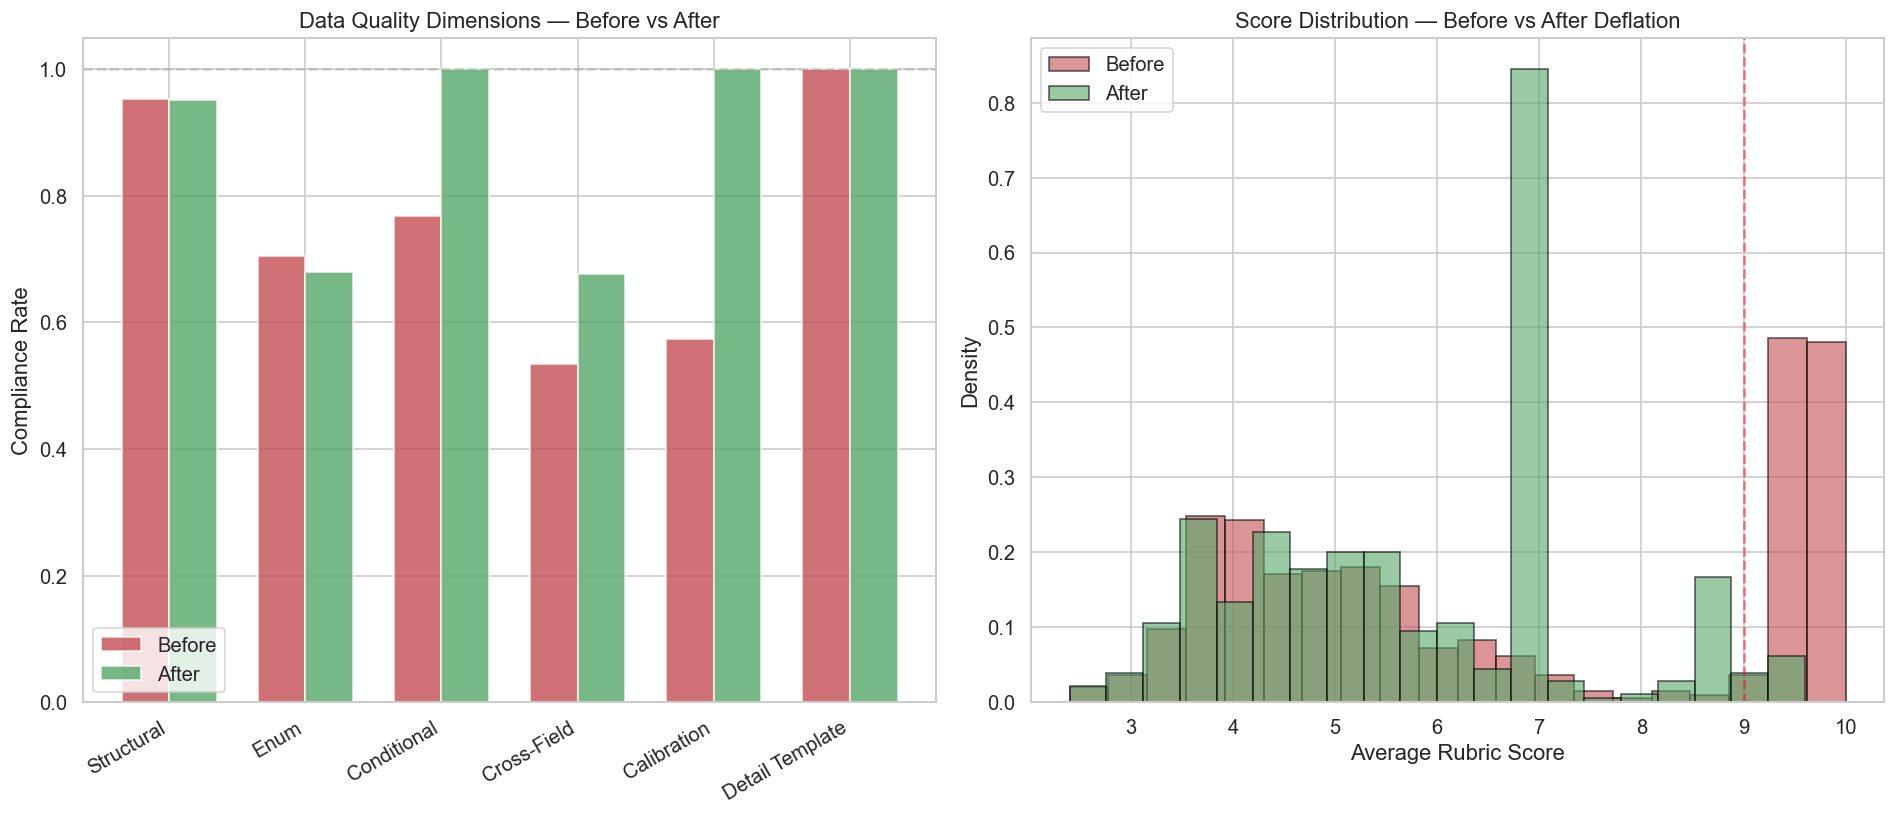

Saved: before_after_quality.png


In [30]:
# ─── Publication-quality comparison visualisations ────────────
if before_metrics and after_metrics:
    # 1. Quality dimensions radar chart
    quality_dims = [
        'structural_compliance_rate', 'enum_compliance_rate',
        'conditional_compliance_rate', 'crossfield_consistency_rate',
        'calibration_compliance_rate', 'detail_template_compliance'
    ]
    dim_labels = ['Structural', 'Enum', 'Conditional', 'Cross-Field',
                  'Calibration', 'Detail Template']

    before_vals = [before_metrics.get(d, 0) for d in quality_dims]
    after_vals = [after_metrics.get(d, 0) for d in quality_dims]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Grouped bar chart (clearer than radar for papers)
    x = np.arange(len(dim_labels))
    width = 0.35
    axes[0].bar(x - width/2, before_vals, width, label='Before', color='#C44E52', alpha=0.8)
    axes[0].bar(x + width/2, after_vals, width, label='After', color='#55A868', alpha=0.8)
    axes[0].set_ylabel('Compliance Rate')
    axes[0].set_title('Data Quality Dimensions — Before vs After')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(dim_labels, rotation=30, ha='right')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend()
    axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

    # Score distribution comparison
    before_scores = []
    after_scores = []
    for r in rows:
        rub = r.get('target_output', {}).get('rubricscores', {})
        if rub:
            before_scores.append(np.mean([rub.get(d, 0) for d in RUBRIC_DIMENSIONS]))
    for r in cleaned_rows:
        rub = r.get('target_output', {}).get('rubricscores', {})
        if rub:
            after_scores.append(np.mean([rub.get(d, 0) for d in RUBRIC_DIMENSIONS]))

    if before_scores and after_scores:
        axes[1].hist(before_scores, bins=20, alpha=0.6, label='Before', color='#C44E52',
                     edgecolor='black', density=True)
        axes[1].hist(after_scores, bins=20, alpha=0.6, label='After', color='#55A868',
                     edgecolor='black', density=True)
        axes[1].set_xlabel('Average Rubric Score')
        axes[1].set_ylabel('Density')
        axes[1].set_title('Score Distribution — Before vs After Deflation')
        axes[1].legend()
        axes[1].axvline(9.0, color='red', linestyle='--', alpha=0.5, label='Pass threshold')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'before_after_quality.png', bbox_inches='tight')
    plt.show()
    print("Saved: before_after_quality.png")

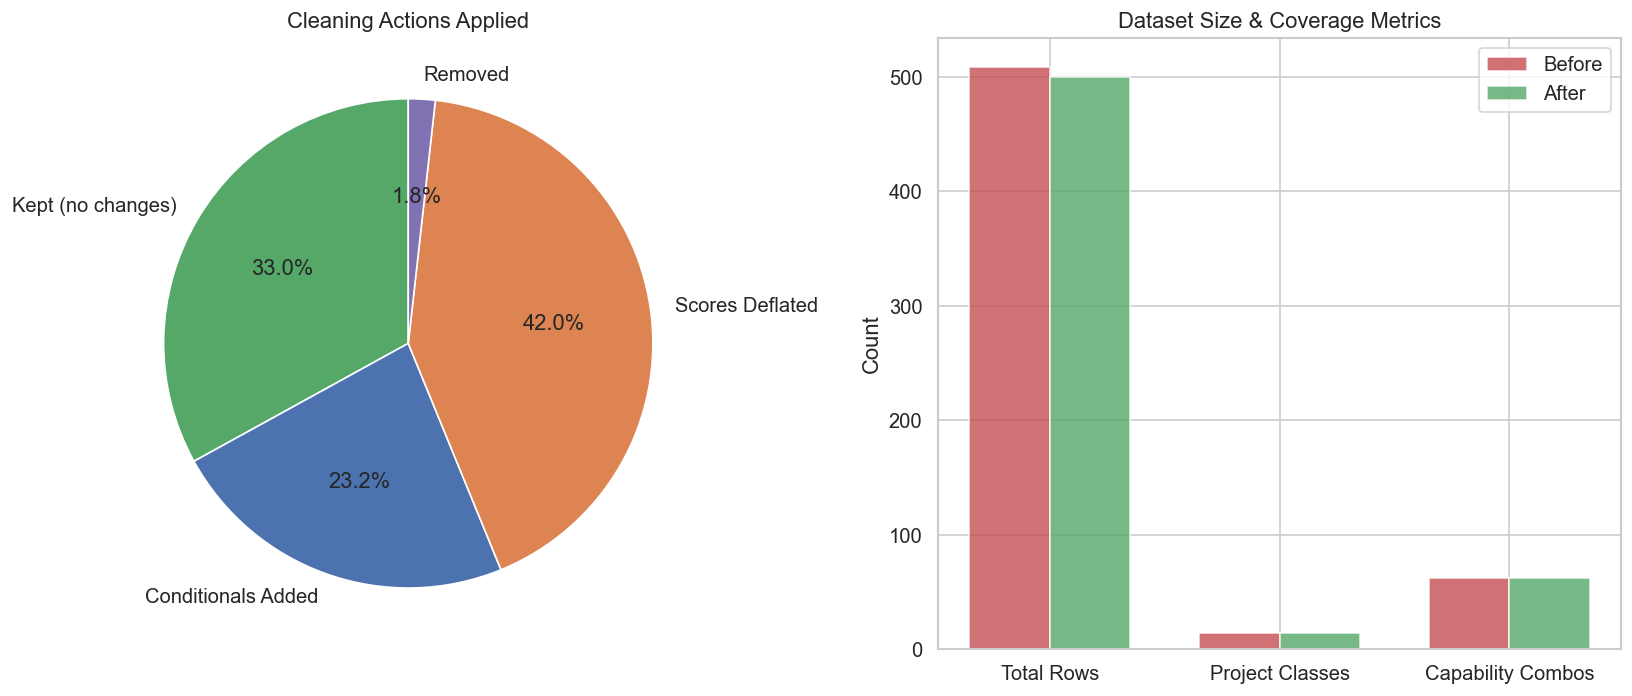

Saved: cleaning_summary.png


In [31]:
# ─── Cleaning summary visualisation ──────────────────────────
if cleaning_log:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Cleaning actions pie chart
    actions = {
        'Kept (no changes)': len(cleaned_rows) - cleaning_log['total_fixes'],
        'Keys Fixed': cleaning_log['fixed_keys'],
        'Enums Fixed': cleaning_log['fixed_enums'],
        'Conditionals Added': cleaning_log['fixed_conditionals'],
        'Scores Deflated': cleaning_log['deflated_scores'],
        'Removed': len(remove_ids),
    }
    actions = {k: v for k, v in actions.items() if v > 0}
    colors = ['#55A868', '#4C72B0', '#DD8452', '#8172B3', '#CCB974', '#C44E52']
    axes[0].pie(actions.values(), labels=actions.keys(), autopct='%1.1f%%',
                colors=colors[:len(actions)], startangle=90)
    axes[0].set_title('Cleaning Actions Applied')

    # Before/after summary metrics bar
    summary_metrics = ['n_rows', 'pc_classes_covered', 'capability_combos']
    summary_labels = ['Total Rows', 'Project Classes', 'Capability Combos']
    before_vals = [before_metrics.get(m, 0) for m in summary_metrics]
    after_vals = [after_metrics.get(m, 0) for m in summary_metrics]

    x = np.arange(len(summary_labels))
    width = 0.35
    axes[1].bar(x - width/2, before_vals, width, label='Before', color='#C44E52', alpha=0.8)
    axes[1].bar(x + width/2, after_vals, width, label='After', color='#55A868', alpha=0.8)
    axes[1].set_ylabel('Count')
    axes[1].set_title('Dataset Size & Coverage Metrics')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(summary_labels)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cleaning_summary.png', bbox_inches='tight')
    plt.show()
    print("Saved: cleaning_summary.png")

---
## Section 14 — Statistical Significance Tests

For academic rigour, we verify that observed improvements are statistically significant
using appropriate non-parametric tests (Wilcoxon for paired comparisons where applicable,
Chi-squared for distribution comparisons).

In [32]:
if rows and cleaned_rows:
    print(f"\n{'='*60}")
    print(f"STATISTICAL SIGNIFICANCE TESTS")
    print(f"{'='*60}")

    # ── Test 1: Score distribution shift ──
    before_scores = []
    after_scores = []

    # Match rows by sample_id for paired test
    cleaned_id_map = {r.get('sample_id'): r for r in cleaned_rows}
    paired_before = []
    paired_after = []

    for r in rows:
        sid = r.get('sample_id')
        rub_before = r.get('target_output', {}).get('rubricscores', {})
        if sid in cleaned_id_map:
            rub_after = cleaned_id_map[sid].get('target_output', {}).get('rubricscores', {})
            if rub_before and rub_after:
                avg_b = np.mean([rub_before.get(d, 0) for d in RUBRIC_DIMENSIONS])
                avg_a = np.mean([rub_after.get(d, 0) for d in RUBRIC_DIMENSIONS])
                paired_before.append(avg_b)
                paired_after.append(avg_a)

    if len(paired_before) > 5:
        # Wilcoxon signed-rank test (paired, non-parametric)
        diffs = np.array(paired_after) - np.array(paired_before)
        non_zero_diffs = diffs[diffs != 0]

        if len(non_zero_diffs) > 0:
            stat, p_val = stats.wilcoxon(non_zero_diffs)
            print(f"\n1. Score Deflation Effect (Wilcoxon signed-rank test)")
            print(f"   Pairs with changes: {len(non_zero_diffs)}")
            print(f"   Mean change: {np.mean(non_zero_diffs):+.3f}")
            print(f"   Statistic: {stat:.3f}, p-value: {p_val:.6f}")
            if p_val < 0.05:
                print(f"   ✓ Statistically significant (p < 0.05)")
            else:
                print(f"   Score changes not statistically significant")
        else:
            print("\n1. No score changes detected (no deflation applied).")

    # ── Test 2: Project class distribution improvement ──
    before_pc = Counter(r.get('profile', {}).get('projectclass', '') for r in rows)
    after_pc = Counter(r.get('profile', {}).get('projectclass', '') for r in cleaned_rows)

    # Chi-squared goodness-of-fit against uniform distribution
    all_classes = sorted(ALLOWED_PROJECT_CLASSES)
    before_observed = [before_pc.get(c, 0) for c in all_classes]
    after_observed = [after_pc.get(c, 0) for c in all_classes]
    expected_uniform = [len(rows) / len(all_classes)] * len(all_classes)
    expected_uniform_after = [len(cleaned_rows) / len(all_classes)] * len(all_classes)

    if sum(before_observed) > 0:
        chi2_before, p_before = stats.chisquare(before_observed, expected_uniform)
        print(f"\n2. Project Class Uniformity (Chi-squared goodness of fit)")
        print(f"   Before: chi2={chi2_before:.2f}, p={p_before:.6f}")

    if sum(after_observed) > 0:
        chi2_after, p_after = stats.chisquare(after_observed, expected_uniform_after)
        print(f"   After:  chi2={chi2_after:.2f}, p={p_after:.6f}")

    # ── Test 3: Rubric dimension independence improvement ──
    print(f"\n3. Rubric Dimension Independence")
    before_rubric_data = []
    after_rubric_data = []
    for r in rows:
        rub = r.get('target_output', {}).get('rubricscores', {})
        if all(d in rub for d in RUBRIC_DIMENSIONS):
            before_rubric_data.append([rub[d] for d in RUBRIC_DIMENSIONS])
    for r in cleaned_rows:
        rub = r.get('target_output', {}).get('rubricscores', {})
        if all(d in rub for d in RUBRIC_DIMENSIONS):
            after_rubric_data.append([rub[d] for d in RUBRIC_DIMENSIONS])

    if before_rubric_data:
        before_corr = np.corrcoef(np.array(before_rubric_data).T)
        after_corr = np.corrcoef(np.array(after_rubric_data).T) if after_rubric_data else before_corr
        before_avg_corr = np.mean(np.abs(before_corr[np.triu_indices(5, k=1)]))
        after_avg_corr = np.mean(np.abs(after_corr[np.triu_indices(5, k=1)]))
        print(f"   Mean |correlation| before: {before_avg_corr:.3f}")
        print(f"   Mean |correlation| after:  {after_avg_corr:.3f}")

    print(f"\n{'='*60}")
    print("All statistical tests complete.")


STATISTICAL SIGNIFICANCE TESTS

1. Score Deflation Effect (Wilcoxon signed-rank test)
   Pairs with changes: 214
   Mean change: -2.020
   Statistic: 0.000, p-value: 0.000000
   ✓ Statistically significant (p < 0.05)

2. Project Class Uniformity (Chi-squared goodness of fit)
   Before: chi2=41.29, p=0.000085
   After:  chi2=39.95, p=0.000141

3. Rubric Dimension Independence
   Mean |correlation| before: 0.727
   Mean |correlation| after:  0.498

All statistical tests complete.


---
## Section 15 — Final Export

Export the cleaned dataset and all validation reports.

In [33]:
if cleaned_rows:
    # ── Export cleaned JSONL ──
    output_path = OUTPUT_DIR / 'auditor_dataset_cleaned.jsonl'
    with open(output_path, 'w', encoding='utf-8') as f:
        for row in cleaned_rows:
            f.write(json.dumps(row, ensure_ascii=False) + '\n')
    print(f"✓ Cleaned dataset exported: {output_path} ({len(cleaned_rows)} rows)")

    # ── Export comparison table ──
    if len(comparison_df) > 0:
        comparison_df.to_csv(OUTPUT_DIR / 'before_after_comparison.csv', index=False)
        print(f"✓ Comparison table exported: {OUTPUT_DIR / 'before_after_comparison.csv'}")

    # ── Export cleaning log ──
    with open(OUTPUT_DIR / 'cleaning_log.json', 'w') as f:
        json.dump(cleaning_log, f, indent=2, default=str)
    print(f"✓ Cleaning log exported: {OUTPUT_DIR / 'cleaning_log.json'}")

    # ── Export validation reports ──
    reports = {
        'structural_violations': {k: v for k, v in all_violations.items()},
        'enum_violations': enum_results,
        'crossfield_violations': {k: v for k, v in crossfield_results.items()},
        'calibration_issues': {k: v for k, v in calibration_results.items()},
    }
    for name, data in reports.items():
        report_path = OUTPUT_DIR / f'{name}.json'
        with open(report_path, 'w') as f:
            json.dump(data, f, indent=2, default=str)
        print(f"✓ {name} exported: {report_path}")

    print(f"\n{'='*60}")
    print(f"ALL OUTPUTS SAVED TO: {OUTPUT_DIR}/")
    print(f"{'='*60}")
else:
    print("No cleaned data to export.")

✓ Cleaned dataset exported: validation_output\auditor_dataset_cleaned.jsonl (500 rows)
✓ Comparison table exported: validation_output\before_after_comparison.csv
✓ Cleaning log exported: validation_output\cleaning_log.json
✓ structural_violations exported: validation_output\structural_violations.json
✓ enum_violations exported: validation_output\enum_violations.json
✓ crossfield_violations exported: validation_output\crossfield_violations.json
✓ calibration_issues exported: validation_output\calibration_issues.json

ALL OUTPUTS SAVED TO: validation_output/


---
## Summary & Conclusions

This notebook implemented a comprehensive, chain-aware validation and cleaning pipeline for the
AuditorAgent synthetic training dataset. The key contributions are:

1. **Chain Reconstruction**: Identified audit chains from shared frozen contracts, enabling
   chain-aware deduplication and progression validation
2. **Seven-Dimension Validation**: Structural schema, enum compliance, cross-field consistency,
   score calibration, diversity, duplication, and bias detection
3. **Intelligent Cleaning**: Context-sensitive fixes including conditional field injection,
   enum normalisation, and score deflation calibrated to plan richness
4. **Quantitative Evidence**: Before/after comparison with statistical significance tests
   demonstrating measurable improvement in dataset quality

### Key Metrics for Thesis Reporting

| Dimension | Evidence |
|-----------|----------|
| Structural Integrity | Schema compliance rate improvement |
| Score Calibration | Anti-inflation violation reduction, score-plan correlation |
| Diversity | Shannon entropy, project class coverage |
| Duplication | Near-duplicate reduction (chain-aware) |
| Bias | ANOVA F-statistics, correlation independence |
| Template Compliance | Issue-detail format adherence |